# EDA
- Hiperparámetros documentados y centralizados en la celda de configuración.

## 1. Setup

In [1]:
from pathlib import Path
from collections import Counter
import json
import re
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torchaudio
from torchcodec.decoders import AudioDecoder

from scipy.stats import skew, kurtosis

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import umap
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [2]:
# Plot configuration

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "legend.frameon": True,
})

In [ ]:
RANDOM_STATE = 42

DATA_ROOT = Path("../data/raw_data")
TRAIN_WAV, TRAIN_JSON = DATA_ROOT / "train" / "wav", DATA_ROOT / "train" / "json"
TEST_WAV, TEST_JSON = DATA_ROOT / "test" / "wav", DATA_ROOT / "test" / "json"

# Si True, se excluyen las grabaciones marcadas como "poor quality" de todo el
# analisis estadistico (no solo de los ejemplos de espectrograma, como en la
# version original). El ruido/artefactos de grabaciones malas puede distorsionar
# medias, PCA y clustering.
EXCLUDE_POOR_QUALITY = True

# Tamano de la muestra para el analisis de features a nivel de grabacion.
# El dataset completo tiene ~6.5k grabaciones: 1000 es un compromiso entre
# velocidad y representatividad. Subir a `None` para usar todo el dataset.
N_ANALYSIS = 1000

# STFT: mismos parametros para features a nivel de grabacion y a nivel de
# segmento, para que sean comparables entre si. n_fft=1024 con hop=256 da
# ~sr/1024 Hz de resolucion en frecuencia, suficiente para separar los rangos
# clinicos de sibilancias/crepitantes (60-2500 Hz aprox.) sin perder demasiada
# resolucion temporal en eventos cortos (crepitantes ~<20ms).
N_FFT = 1024
HOP_LENGTH = 256

# Mel-spectrogram (solo para visualizacion)
TARGET_SR = 4000
N_MELS = 64

# Bandas de energia relevantes para sonidos respiratorios
RESPIRATORY_BANDS = {
    "band_0_100": (0, 100),
    "band_100_300": (100, 300),
    "band_300_600": (300, 600),
    "band_600_1200": (600, 1200),
    "band_1200_2000": (1200, 2000),
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Torchaudio:", torchaudio.__version__)
print("Device:", DEVICE)

PyTorch: 2.11.0+cu126
Torchaudio: 2.11.0+cu126
Device: cuda


In [4]:
EVENT_TYPE_NORM = {
    "normal": "N",
    "rhonchi": "R",
    "wheeze": "W",
    "stridor": "S",
    "coarse crackle": "CC",
    "fine crackle": "FC",
    "wheeze&crackle": "WC",
    "wheeze+crackle": "WC",
}

CLASS_NAMES = {
    "N": "Normal",
    "R": "Rhonchi",
    "W": "Wheeze",
    "S": "Stridor",
    "CC": "Coarse Crackle",
    "FC": "Fine Crackle",
    "WC": "Wheeze + Crackle",
}

LOCATION_NAMES = {
    "p1": "left_posterior",
    "p2": "right_posterior",
    "p3": "left_anterior",
    "p4": "right_anterior",
    "p5": "left_lateral",
    "p6": "right_lateral",
}

## 2. Auxiliary functions

In [5]:
def plot_hist(data, x, hue=None, bins=40, title="", xlabel=None, ylabel="Count",
              kde=True, element="step", log_scale=False, ax=None, figsize=(10, 5)):
    """Histograma con estilo consistente (reemplaza ~15 bloques repetidos)."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=figsize)

    sns.histplot(
        data=data, x=x, hue=hue, bins=bins, kde=kde,
        element=element, log_scale=log_scale, ax=ax,
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel if xlabel is not None else x)
    ax.set_ylabel(ylabel)

    if own_fig:
        plt.tight_layout()
        plt.show()
    return ax


def plot_scatter_2d(data, x, y, hue=None, style=None, title="", alpha=0.6, s=40,
                     palette=None, figsize=(11, 7)):
    """Scatter 2D con estilo consistente, usado para PCA/UMAP/clusters."""
    plt.figure(figsize=figsize)
    sns.scatterplot(data=data, x=x, y=y, hue=hue, style=style, alpha=alpha, s=s, palette=palette)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def scale_and_reduce(df_features, n_neighbors=30, min_dist=0.15, metric="euclidean",
                      random_state=RANDOM_STATE):
    """Imputa, escala, corre PCA (todas las componentes) y UMAP (2D).

    Devuelve: X_scaled, pca (fit), X_pca, X_umap
    """
    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(
        df_features.replace([np.inf, -np.inf], np.nan)
    )

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    pca = PCA(random_state=random_state)
    X_pca = pca.fit_transform(X_scaled)

    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state,
    )
    X_umap = reducer.fit_transform(X_scaled)

    return X_scaled, pca, X_pca, X_umap


def plot_pca_variance(pca, title="PCA explained variance"):
    explained = pca.explained_variance_ratio_
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(np.arange(1, len(explained) + 1), np.cumsum(explained), marker="o")
    ax.axhline(0.90, linestyle="--", color="gray", label="90%")
    ax.axhline(0.95, linestyle="--", color="black", label="95%")
    ax.set_xlabel("Number of principal components")
    ax.set_ylabel("Cumulative explained variance")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


def kmeans_silhouette_scan(X_scaled, k_range=range(2, 11), random_state=RANDOM_STATE, n_init=20):
    results = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        results.append({"k": k, "silhouette": score})
    return pd.DataFrame(results)

## 3. Data loading
---

In [6]:
def normalize_event_type(event_type):
    if event_type is None:
        return None
    x = str(event_type).strip().lower()
    return EVENT_TYPE_NORM.get(x, x)


def parse_stem(stem):
    """
    Formato esperado: 0001_25_0_p1_1
    Devuelve: patient_id, gender, location, recording
    """
    stem_clean = re.sub(r"^\d{4}__", "", stem)
    parts = stem_clean.split("_")

    if len(parts) < 5:
        return {"patient_id": None, "gender": None, "location": None, "recording": None}

    return {
        "patient_id": parts[0],
        "gender": int(parts[2]) if parts[2].isdigit() else None,
        "location": parts[3],
        "recording": parts[4],
    }


def build_file_index():
    rows = []

    for split, wav_dir, json_dir in [
        ("train", TRAIN_WAV, TRAIN_JSON),
        ("test", TEST_WAV, TEST_JSON),
    ]:
        for wav_path in sorted(wav_dir.glob("*.wav")):
            json_path = json_dir / f"{wav_path.stem}.json"
            info = parse_stem(wav_path.stem)

            match = re.match(r"^(\d{4})__", wav_path.stem)
            source = match.group(1) if match else None

            rows.append({
                "split": split,
                "source": source,
                "stem": wav_path.stem,
                "wav_path": wav_path,
                "json_path": json_path,
                **info,
                "location_name": LOCATION_NAMES.get(info["location"], info["location"]),
                "gender_name": {0: "Male", 1: "Female"}.get(info["gender"], "Unknown"),
                "json_exists": json_path.exists(),
            })

    return pd.DataFrame(rows)


def load_annotation(json_path):
    if not json_path.exists():
        return {"record_annotation": None, "events": []}

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    events = [
        {
            "type_raw": event.get("type"),
            "type": normalize_event_type(event.get("type")),
            "start_ms": event.get("start"),
            "end_ms": event.get("end"),
        }
        for event in data.get("event_annotation", [])
    ]

    return {"record_annotation": data.get("record_annotation"), "events": events}


def get_record_classes(events):
    return sorted(set(e["type"] for e in events if e["type"] in CLASS_NAMES))


df = build_file_index()

annotations = df["json_path"].apply(load_annotation)
df["record_annotation"] = annotations.apply(lambda x: x["record_annotation"])
df["events"] = annotations.apply(lambda x: x["events"])
df["n_events"] = df["events"].apply(len)
df["poor_quality"] = df["record_annotation"].astype(str).str.lower().eq("poor quality")
df["classes"] = df["events"].apply(get_record_classes)

print(f"Total recordings: {len(df):,}\n")
print(df["split"].value_counts(), "\n")
print(df["source"].value_counts(dropna=False))

Total recordings: 6,567

split
train    5258
test     1309
Name: count, dtype: int64 

source
2022    2683
2024    1704
2025    1309
2023     871
Name: count, dtype: int64


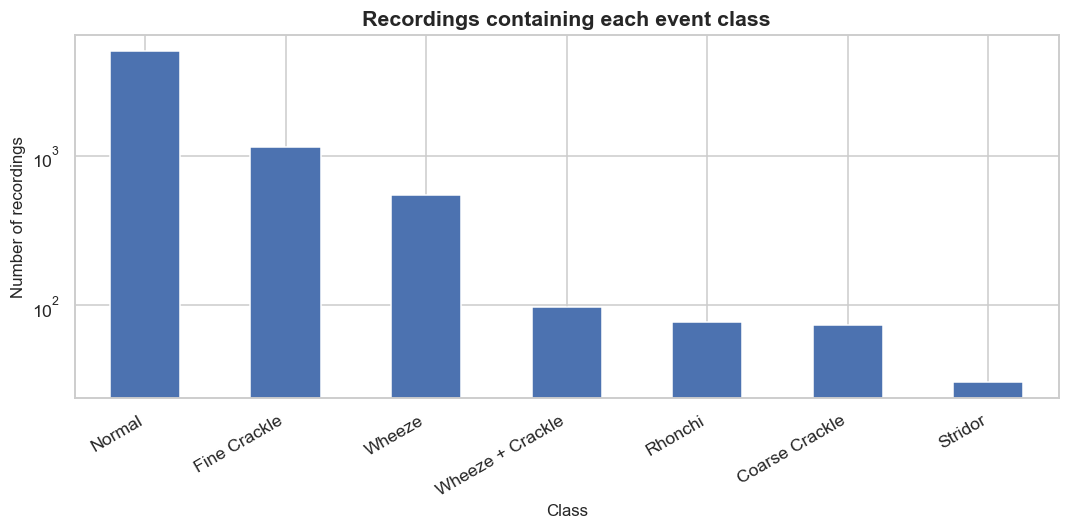

In [72]:
class_counts = Counter(cls for classes in df["classes"] for cls in classes)
class_counts = pd.Series(class_counts).sort_values(ascending=False)
class_counts.index = [CLASS_NAMES.get(x, x) for x in class_counts.index]

class_counts.plot.bar(figsize=(10, 5))
plt.title("Recordings containing each event class")
plt.ylabel("Number of recordings")
plt.xlabel("Class")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.yscale('log')
plt.show()

## 4. Data quality

In [8]:
print("Missing JSON:", (~df["json_exists"]).sum())
print("Poor quality:", df["poor_quality"].sum())
print("Duplicate stems:", df["stem"].duplicated().sum())
print(
    "Duplicate patient/location/recording:",
    df[["patient_id", "location", "recording"]].duplicated().sum(),
)

Missing JSON: 0
Poor quality: 230
Duplicate stems: 0
Duplicate patient/location/recording: 0


In [9]:
if EXCLUDE_POOR_QUALITY:
    n_before = len(df)
    df = df.loc[~df["poor_quality"]].reset_index(drop=True)
    print(f"Excluded {n_before - len(df)} poor-quality recordings -> {len(df)} remain.")

Excluded 230 poor-quality recordings -> 6337 remain.


## 5. Metadata: gender, location, year

In [10]:
display(df.head())
print("\nDataset dimensions:", df.shape)
print("\nMissing values:")
display(
    df[["patient_id", "gender", "location", "recording", "source", "split", "record_annotation"]]
    .isna()
    .sum()
)

,split,source,stem,wav_path,json_path,patient_id,gender,location,recording,location_name,gender_name,json_exists,record_annotation,events,n_events,poor_quality,classes
0,train,2022,2022__40138127_14.7_0_p3_139,..\data\raw_data\train\wav\2022__40138127_14.7...,..\data\raw_data\train\json\2022__40138127_14....,40138127,0,p3,139,left_anterior,Male,True,Normal,"[{'type_raw': 'Normal', 'type': 'N', 'start_ms...",1,False,[N]
1,train,2022,2022__40138127_14.7_0_p4_140,..\data\raw_data\train\wav\2022__40138127_14.7...,..\data\raw_data\train\json\2022__40138127_14....,40138127,0,p4,140,right_anterior,Male,True,Normal,"[{'type_raw': 'Normal', 'type': 'N', 'start_ms...",1,False,[N]
2,train,2022,2022__40490865_8.4_1_p1_1884,..\data\raw_data\train\wav\2022__40490865_8.4_...,..\data\raw_data\train\json\2022__40490865_8.4...,40490865,1,p1,1884,left_posterior,Female,True,Normal,"[{'type_raw': 'Normal', 'type': 'N', 'start_ms...",4,False,[N]
3,train,2022,2022__40490865_8.4_1_p2_1900,..\data\raw_data\train\wav\2022__40490865_8.4_...,..\data\raw_data\train\json\2022__40490865_8.4...,40490865,1,p2,1900,right_posterior,Female,True,Normal,"[{'type_raw': 'Normal', 'type': 'N', 'start_ms...",4,False,[N]
4,train,2022,2022__40490865_8.4_1_p3_1916,..\data\raw_data\train\wav\2022__40490865_8.4_...,..\data\raw_data\train\json\2022__40490865_8.4...,40490865,1,p3,1916,left_anterior,Female,True,Normal,"[{'type_raw': 'Normal', 'type': 'N', 'start_ms...",3,False,[N]



Dataset dimensions: (6337, 17)

Missing values:


patient_id              0
gender                  0
location                0
recording               0
source                  0
split                   0
record_annotation    3013
dtype: int64

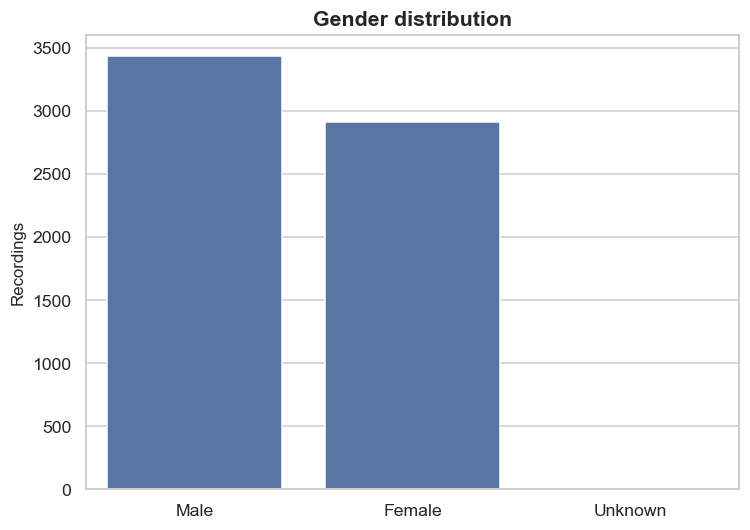

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x="gender_name", order=["Male", "Female", "Unknown"], ax=ax)
ax.set_title("Gender distribution")
ax.set_xlabel("")
ax.set_ylabel("Recordings")
plt.tight_layout()
plt.show()

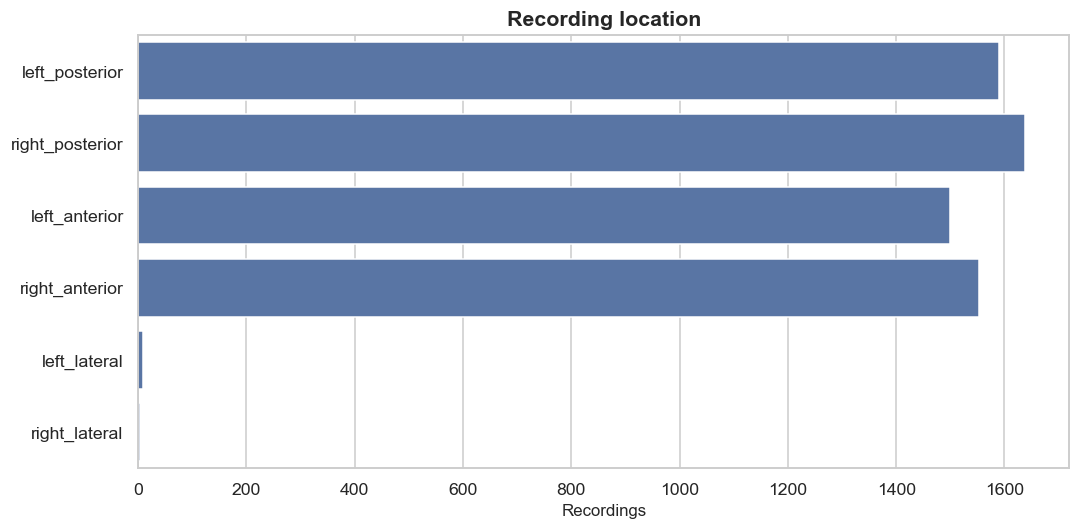

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
location_order = [
    "left_posterior", "right_posterior", "left_anterior",
    "right_anterior", "left_lateral", "right_lateral",
]
sns.countplot(data=df, y="location_name", order=location_order, ax=ax)
ax.set_title("Recording location")
ax.set_xlabel("Recordings")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

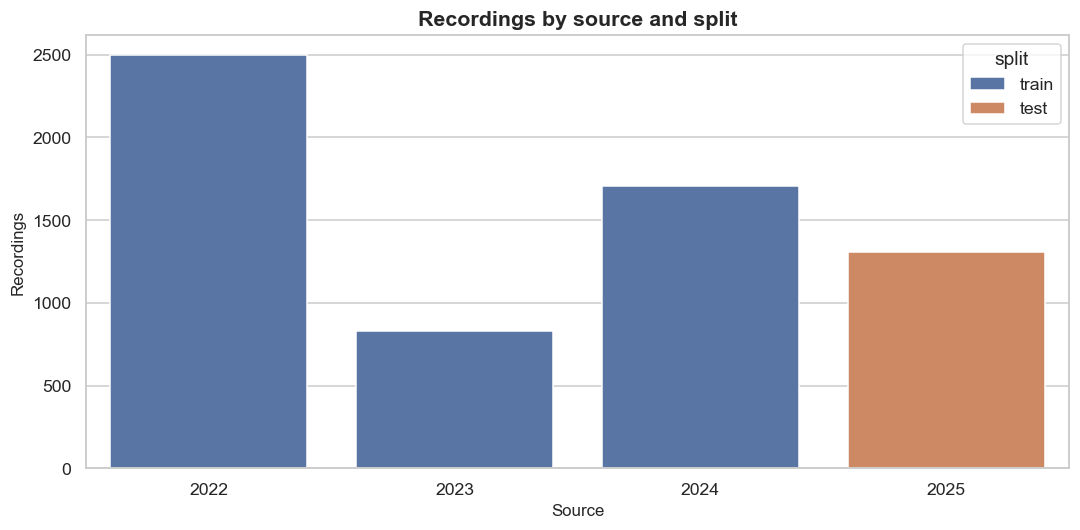

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x="source", hue="split", ax=ax)
ax.set_title("Recordings by source and split")
ax.set_xlabel("Source")
ax.set_ylabel("Recordings")
plt.tight_layout()
plt.show()

## 6. Recordings length

In [14]:
def get_audio_info(path):
    try:
        info = AudioDecoder(str(path)).metadata
        num_frames = int(info.duration_seconds * info.sample_rate)
        return {
            "sample_rate": info.sample_rate,
            "num_frames": num_frames,
            "num_channels": info.num_channels,
            "duration_s": num_frames / info.sample_rate,
        }
    except Exception:
        return {"sample_rate": None, "num_frames": None, "num_channels": None, "duration_s": None}


audio_info_df = pd.DataFrame(df["wav_path"].apply(get_audio_info).tolist())
df = pd.concat([df.reset_index(drop=True), audio_info_df], axis=1)

display(df[["split", "source", "sample_rate", "num_channels", "duration_s"]].describe(include="all"))

,split,source,sample_rate,num_channels,duration_s
count,6337,6337,6337.0,6337.0,6337.000000
unique,2,4,NaN,NaN,NaN
top,train,2022,NaN,NaN,NaN
freq,5028,2496,NaN,NaN,NaN
mean,NaN,NaN,8000.0,1.0,11.460066
std,NaN,NaN,0.0,0.0,3.054997
min,NaN,NaN,8000.0,1.0,2.336000
25%,NaN,NaN,8000.0,1.0,9.216000
50%,NaN,NaN,8000.0,1.0,9.216000
75%,NaN,NaN,8000.0,1.0,15.360000


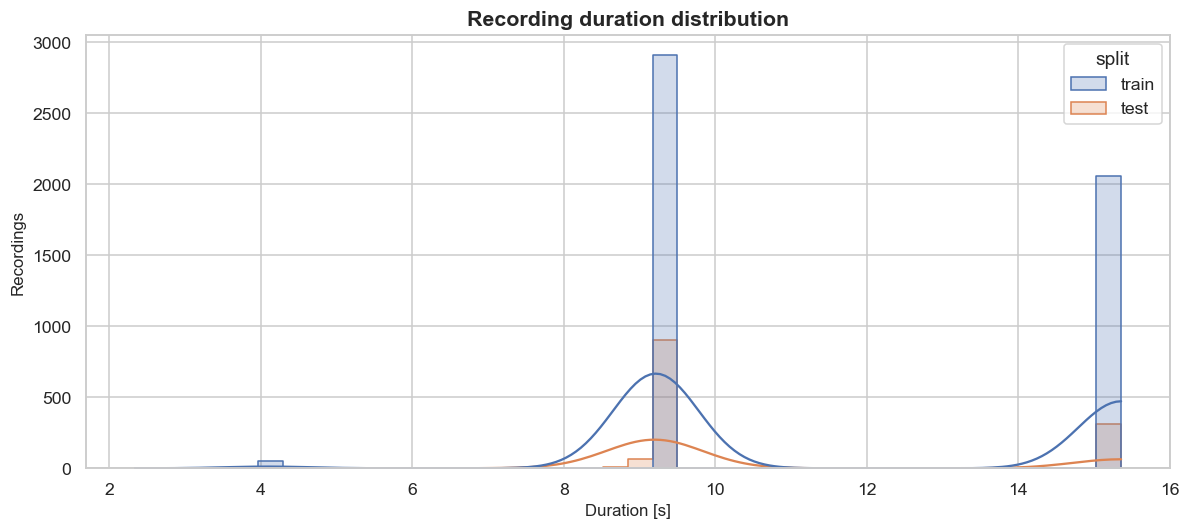

<Axes: title={'center': 'Recording duration distribution'}, xlabel='Duration [s]', ylabel='Recordings'>

In [15]:
plot_hist(df, x="duration_s", hue="split", title="Recording duration distribution", xlabel="Duration [s]", ylabel="Recordings", figsize=(11, 5))

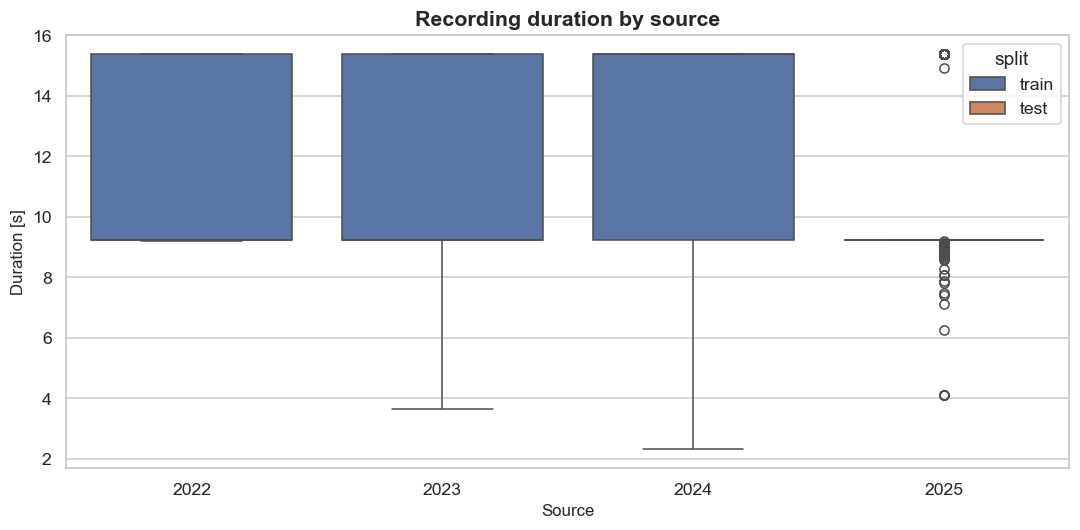

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="source", y="duration_s", hue="split", ax=ax)
ax.set_title("Recording duration by source")
ax.set_xlabel("Source")
ax.set_ylabel("Duration [s]")
plt.tight_layout()
plt.show()

In [17]:
print("Duration statistics:")
display(df.groupby(["split", "source"])["duration_s"].describe().round(2))

Duration statistics:


count   mean   std   min   25%    50%    75%    max
split source                                                      
test  2025    1309.0  10.63  2.65  4.10  9.22   9.22   9.22  15.36
train 2022    2496.0  11.02  2.80  9.18  9.22   9.22  15.36  15.36
      2023     828.0  11.87  3.22  3.65  9.22   9.22  15.36  15.36
      2024    1704.0  12.54  3.28  2.34  9.22  15.36  15.36  15.36

## 7. Recordings acoustic features

In [18]:
def load_audio(path):
    waveform, sr = torchaudio.load(str(path))
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    return waveform, sr


def amplitude_temporal_features(x_np):
    """Features de amplitud + temporales sobre la senal en dominio del tiempo."""
    abs_x = np.abs(x_np)

    rms = float(np.sqrt(np.mean(x_np ** 2)))
    peak = float(np.max(abs_x))
    mean_abs = float(np.mean(abs_x))
    std = float(np.std(x_np))
    crest_factor = peak / (rms + 1e-12)

    # Zero crossing rate (definicion unica y consistente en todo el notebook)
    zcr = float(np.mean(np.diff(np.signbit(x_np)) != 0))

    energy = float(np.mean(x_np ** 2))
    skewness = float(skew(x_np))
    kurt = float(kurtosis(x_np))

    p01, p99 = np.percentile(abs_x, [1, 99])
    dynamic_range = float(p99 / (p01 + 1e-12))

    return {
        "rms": rms, "peak": peak, "mean_abs": mean_abs, "std": std,
        "crest_factor": crest_factor, "zcr": zcr, "energy": energy,
        "skewness": skewness, "kurtosis": kurt, "dynamic_range": dynamic_range,
    }


def spectral_features(x_tensor, sr, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """Features espectrales via STFT. Mismos parametros que a nivel de segmento."""
    spec = torch.stft(
        x_tensor, n_fft=n_fft, hop_length=hop_length,
        win_length=n_fft, return_complex=True,
    )
    magnitude = spec.abs()
    freqs = torch.fft.rfftfreq(n_fft, d=1 / sr).to(magnitude.device)

    spectrum = magnitude.mean(dim=1)
    eps = 1e-12
    total = spectrum.sum() + eps

    centroid = (freqs * spectrum).sum() / total
    bandwidth = torch.sqrt(((freqs - centroid) ** 2 * spectrum).sum() / total)

    cumulative = torch.cumsum(spectrum, dim=0)
    rolloff_idx = min(torch.searchsorted(cumulative, 0.85 * total).item(), len(freqs) - 1)
    rolloff = freqs[rolloff_idx]

    dominant_idx = torch.argmax(spectrum)
    dominant_freq = freqs[dominant_idx]

    return {
        "spectral_centroid": centroid.item(),
        "spectral_bandwidth": bandwidth.item(),
        "spectral_rolloff": rolloff.item(),
        "dominant_frequency": dominant_freq.item(),
    }


def extract_record_features(path):
    waveform, sr = load_audio(path)
    x_np = waveform.squeeze(0).numpy()

    features = amplitude_temporal_features(x_np)
    features.update(spectral_features(waveform.squeeze(0).to(DEVICE), sr))
    return features

In [19]:
n_analysis = len(df) if N_ANALYSIS is None else min(N_ANALYSIS, len(df))
analysis_idx = df.sample(n_analysis, random_state=RANDOM_STATE).index

record_features = [
    extract_record_features(df.loc[i, "wav_path"])
    for i in tqdm(analysis_idx, desc="Extracting record-level features")
]

record_features_df = pd.DataFrame(record_features, index=analysis_idx)
df.loc[analysis_idx, record_features_df.columns] = record_features_df

df["rms_db"] = 20 * np.log10(df["rms"].clip(lower=1e-8))

Extracting record-level features:   0%|          | 0/1000 [00:00<?, ?it/s]

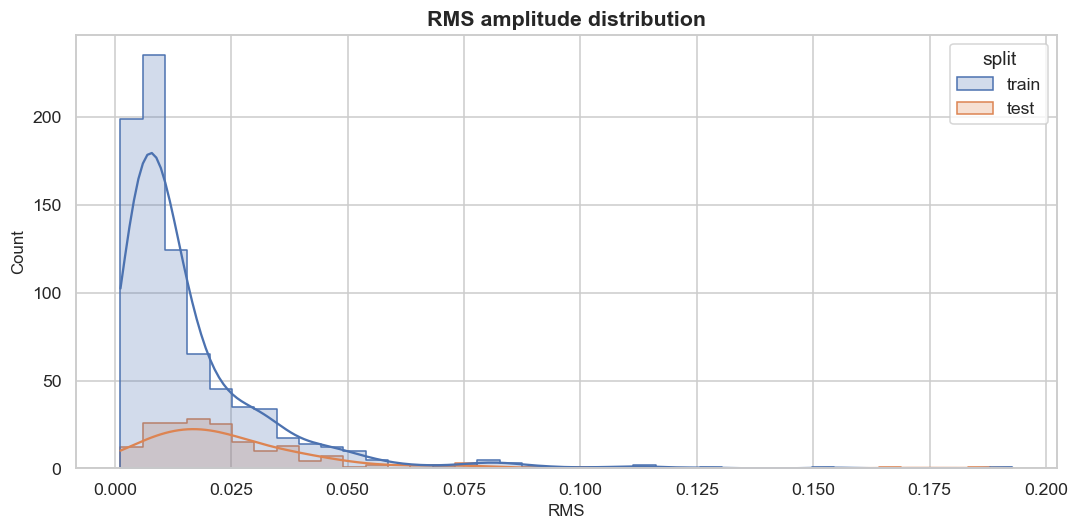

<Axes: title={'center': 'RMS amplitude distribution'}, xlabel='RMS', ylabel='Count'>

In [20]:
plot_hist(df.loc[analysis_idx], x="rms", hue="split", title="RMS amplitude distribution", xlabel="RMS")

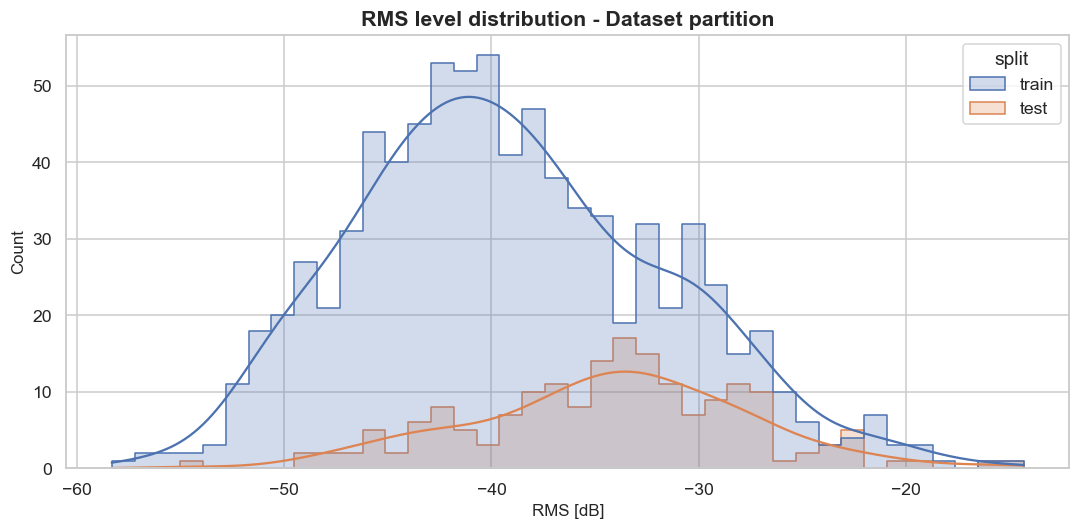

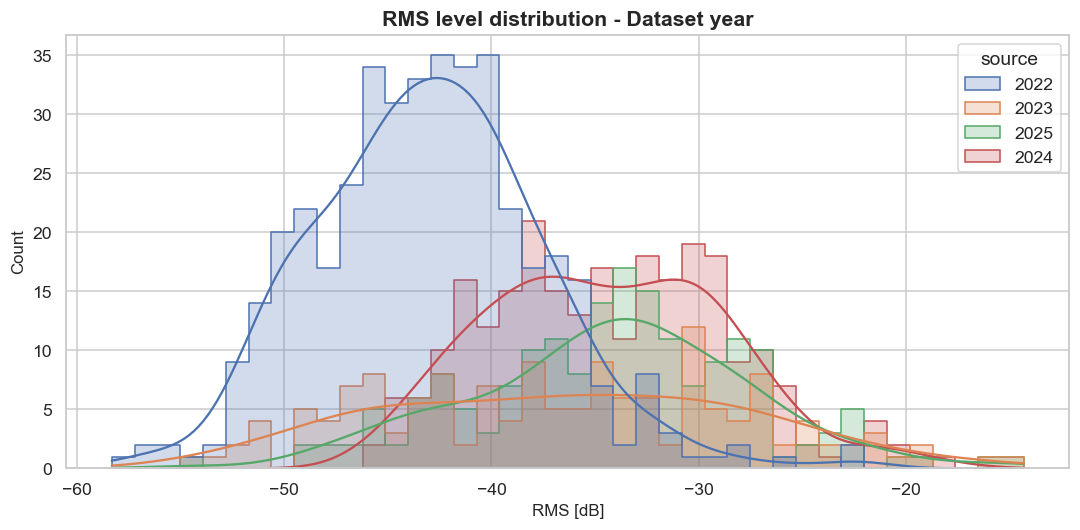

<Axes: title={'center': 'RMS level distribution - Dataset year'}, xlabel='RMS [dB]', ylabel='Count'>

In [21]:
plot_hist(df.loc[analysis_idx], x="rms_db", hue="split", title="RMS level distribution - Dataset partition", xlabel="RMS [dB]")
plot_hist(df.loc[analysis_idx], x="rms_db", hue="source", title="RMS level distribution - Dataset year", xlabel="RMS [dB]")

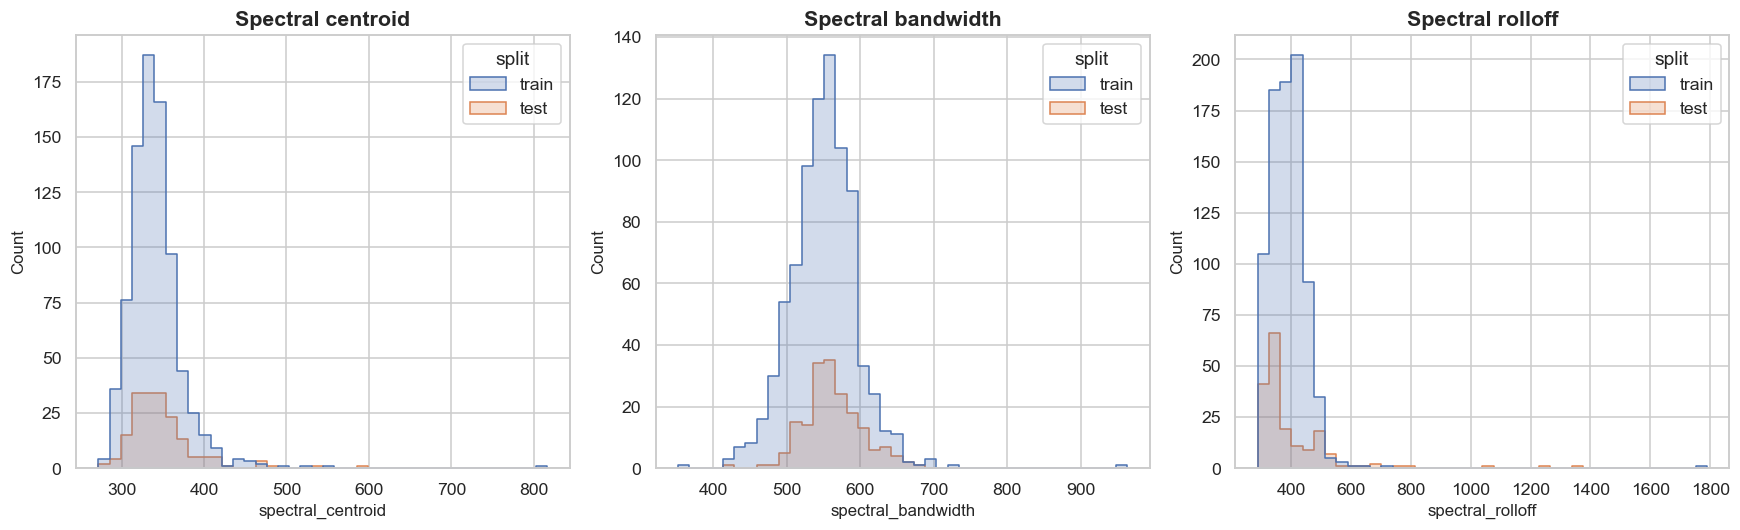

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(
    axes,
    ["spectral_centroid", "spectral_bandwidth", "spectral_rolloff"],
    ["Spectral centroid", "Spectral bandwidth", "Spectral rolloff"],
):
    plot_hist(df.loc[analysis_idx], x=col, hue="split", title=title, kde=False, ax=ax)
plt.tight_layout()
plt.show()

### Spectrograms examples

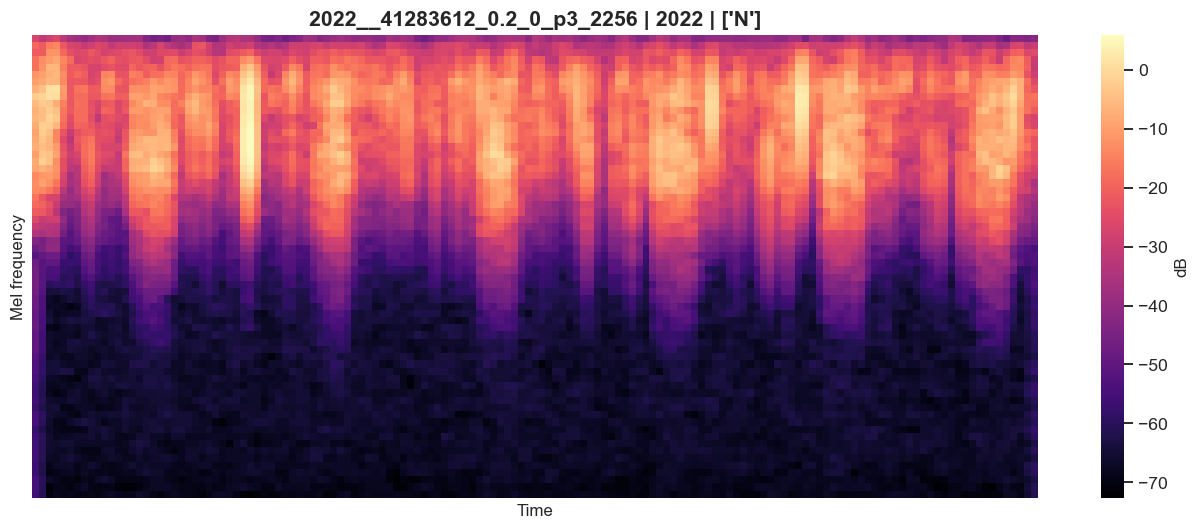

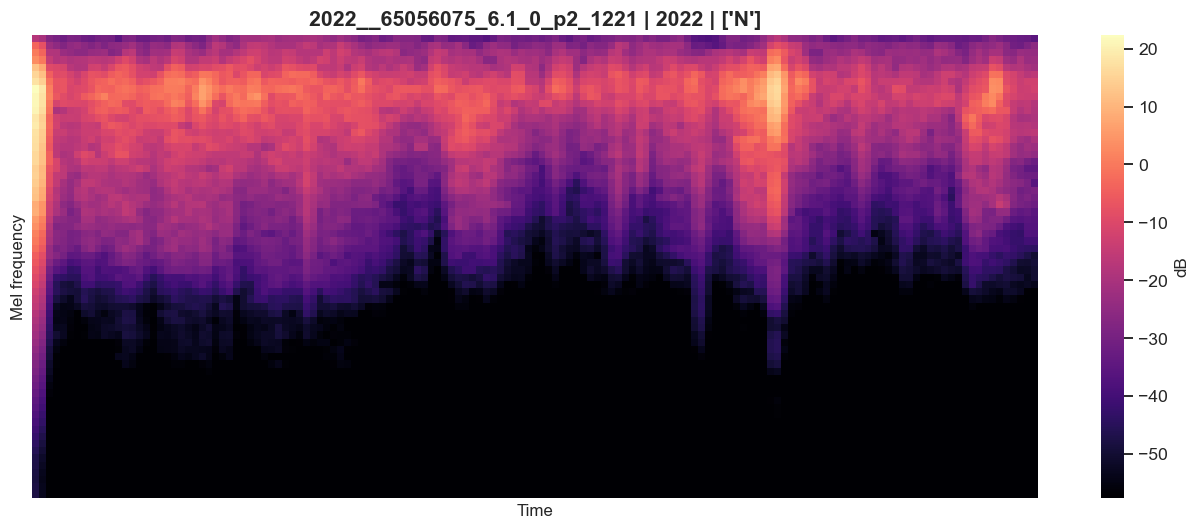

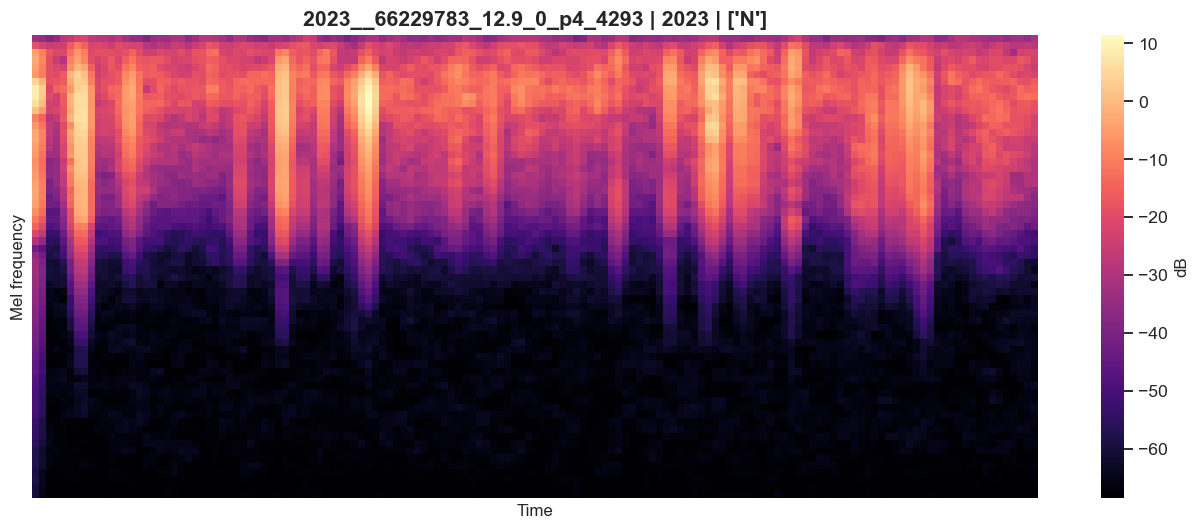

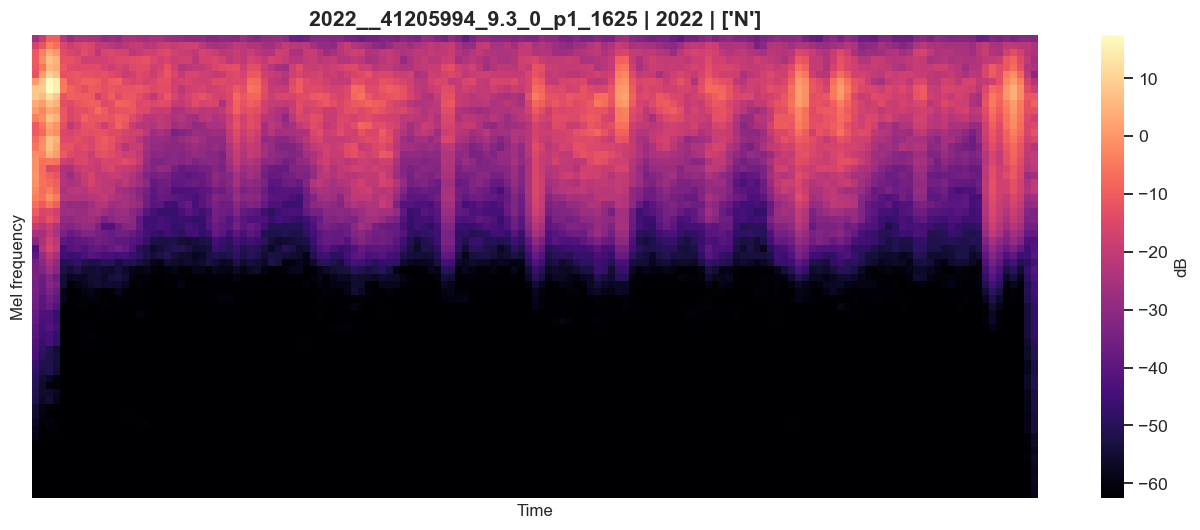

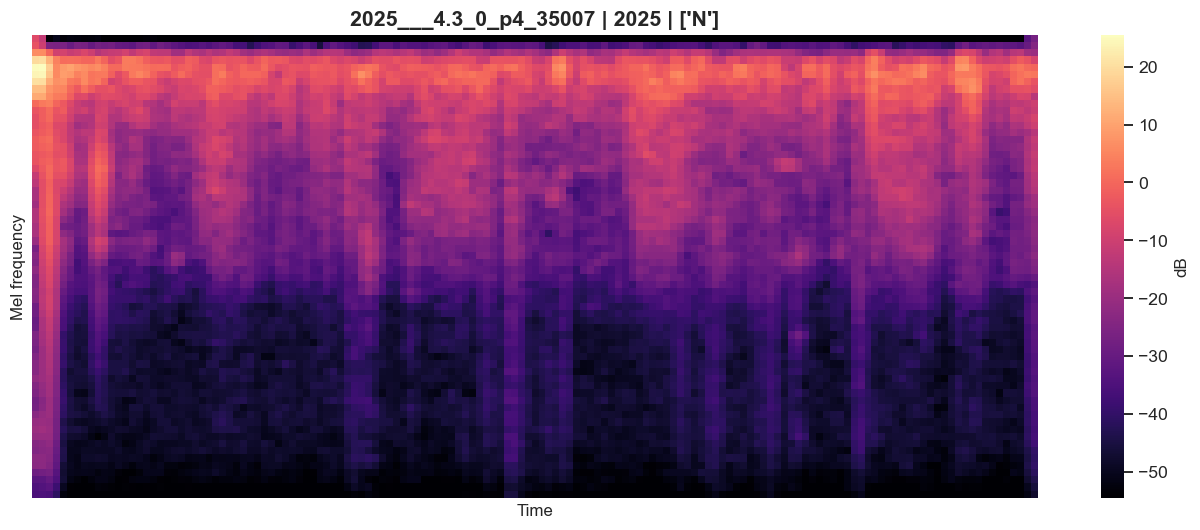

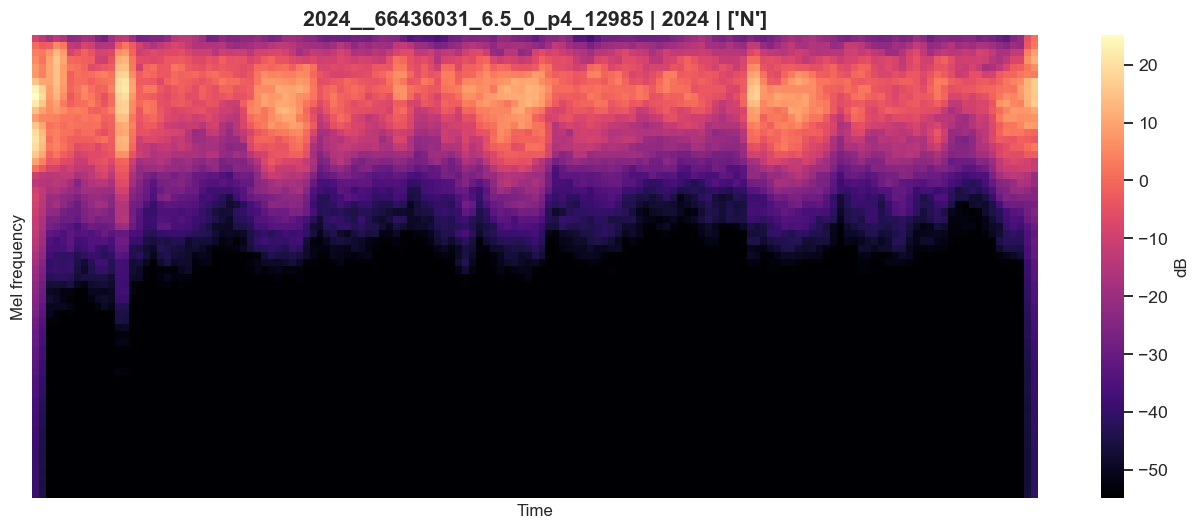

In [23]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=TARGET_SR, n_fft=1024, hop_length=256, n_mels=N_MELS, f_min=1, f_max=TARGET_SR // 2,
)
db_transform = torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80)


def get_mel_spectrogram(path):
    waveform, sr = torchaudio.load(str(path))
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != TARGET_SR:
        waveform = torchaudio.functional.resample(waveform, sr, TARGET_SR)
    return db_transform(mel_transform(waveform)).squeeze(0)


def plot_spectrogram(path, title=None, figsize=(12, 5)):
    mel_db = get_mel_spectrogram(path)
    plt.figure(figsize=figsize)
    sns.heatmap(mel_db.numpy(), cmap="magma", xticklabels=False, yticklabels=False, cbar_kws={"label": "dB"})
    plt.title(title or Path(path).stem)
    plt.xlabel("Time")
    plt.ylabel("Mel frequency")
    plt.tight_layout()
    plt.show()


examples = df[df["n_events"] > 0].sample(6, random_state=RANDOM_STATE)
for _, row in examples.iterrows():
    plot_spectrogram(row["wav_path"], title=f"{row['stem']} | {row['source']} | {row['classes']}")

## 8. Records distribution and correlation

In [24]:
FEATURE_COLUMNS = [
    "duration_s", "rms", "peak", "mean_abs", "std", "crest_factor", "rms_db",
    "zcr", "energy", "skewness", "kurtosis", "dynamic_range",
    "spectral_centroid", "spectral_bandwidth", "spectral_rolloff", "dominant_frequency",
]
available_features = [c for c in FEATURE_COLUMNS if c in df.columns]

display(df[available_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
duration_s,6337.0,1.146007e+01,3.054997e+00,2.336000,9.216000,9.216000,1.536000e+01,1.536000e+01
rms,1000.0,1.805674e-02,1.976707e-02,0.001212,0.006474,0.011553,2.270792e-02,1.927598e-01
peak,1000.0,4.790065e-01,3.277011e-01,0.024445,0.198143,0.386047,7.555313e-01,1.000000e+00
mean_abs,1000.0,6.333324e-03,7.247333e-03,0.000672,0.002238,0.004438,7.669955e-03,7.173456e-02
std,1000.0,1.805671e-02,1.976701e-02,0.001212,0.006474,0.011553,2.270791e-02,1.927595e-01
crest_factor,1000.0,3.257626e+01,1.452944e+01,4.900083,21.585437,30.578651,4.285789e+01,8.575956e+01
rms_db,1000.0,-3.827333e+01,7.518389e+00,-58.326928,-43.776840,-38.746078,-3.287651e+01,-1.429967e+01
zcr,1000.0,4.032113e-02,5.618782e-03,0.028009,0.036944,0.039497,4.293542e-02,9.810517e-02
energy,1000.0,7.163922e-04,2.410228e-03,0.000001,0.000042,0.000133,5.156564e-04,3.715636e-02
skewness,1000.0,-1.932240e-01,4.481269e+00,-16.673971,-1.464922,-0.050413,1.238856e+00,2.865731e+01


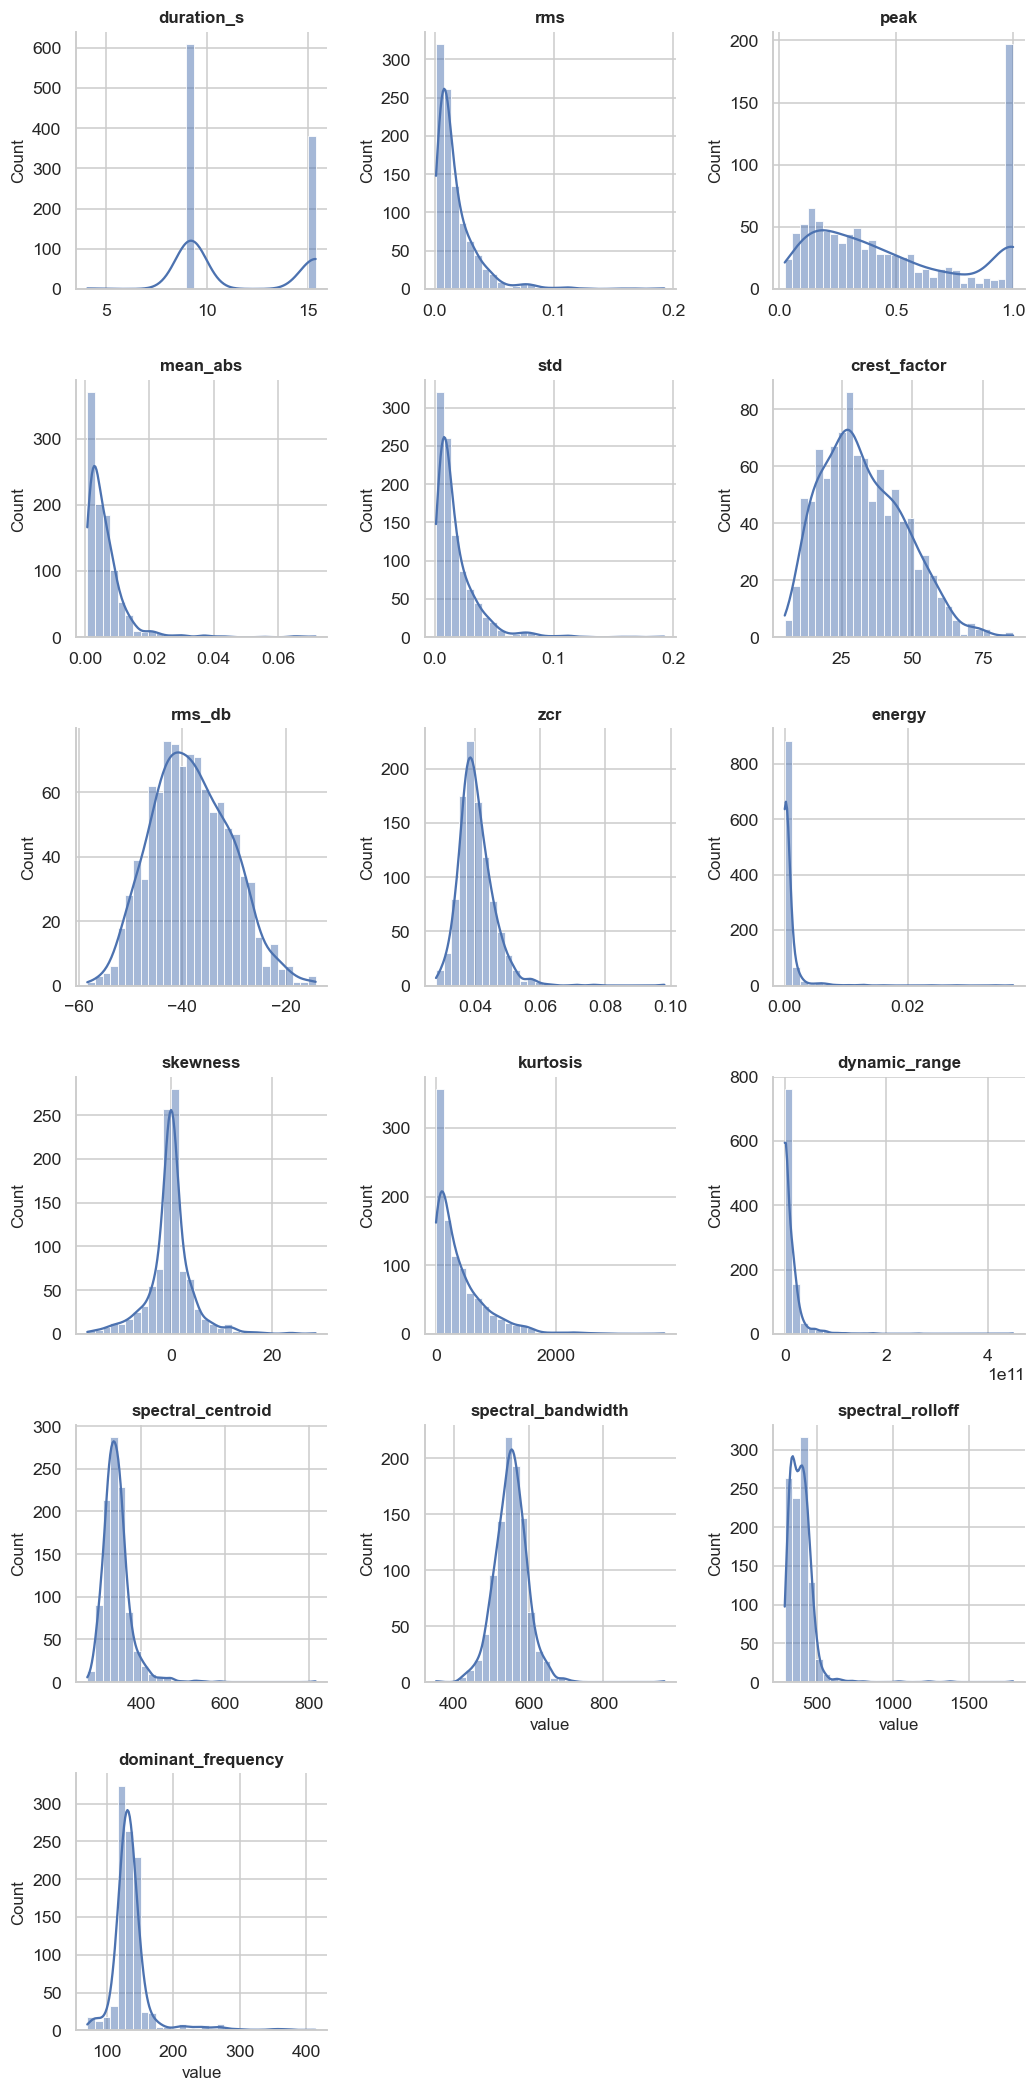

In [25]:
long_df = df.loc[analysis_idx, available_features].melt(var_name="feature", value_name="value")
g = sns.FacetGrid(long_df, col="feature", col_wrap=3, height=3.2, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x="value", bins=30, kde=True)
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

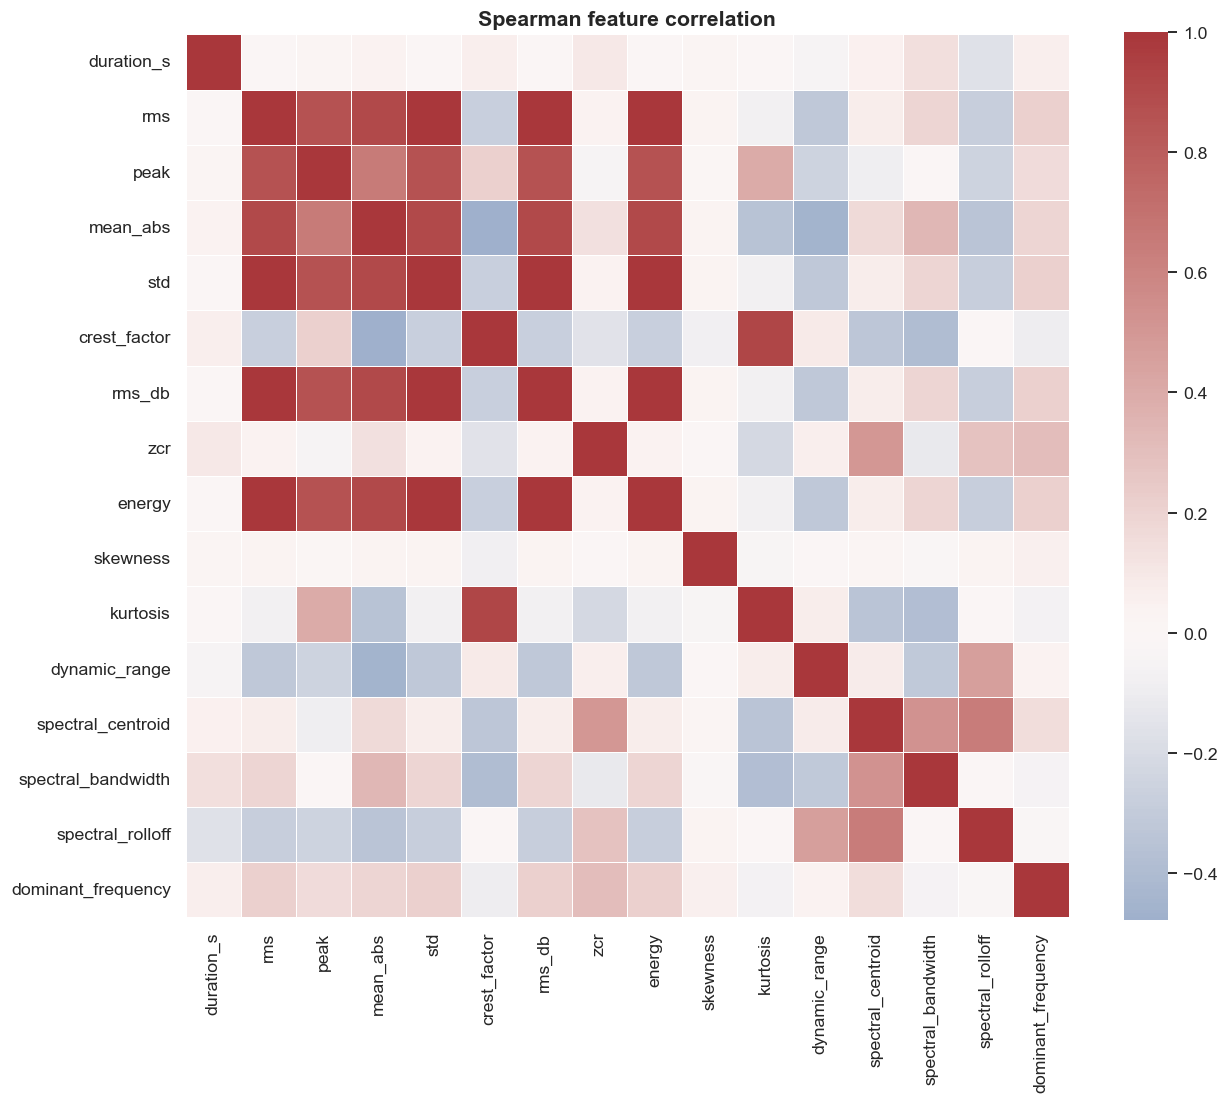

In [26]:
corr = df[available_features].corr(method="spearman")
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="vlag", center=0, square=True, linewidths=0.5)
plt.title("Spearman feature correlation")
plt.tight_layout()
plt.show()

## 10. Analisis de pacientes y particion train/test

In [27]:
print("Unique patients:", df["patient_id"].nunique())
print("Unique recordings:", len(df))
print("\nRecordings per patient:")
display(df.groupby("patient_id").size().describe())

Unique patients: 860
Unique recordings: 6337

Recordings per patient:


count    860.000000
mean       7.368605
std       14.818426
min        1.000000
25%        3.000000
50%        5.000000
75%        8.250000
max      387.000000
dtype: float64

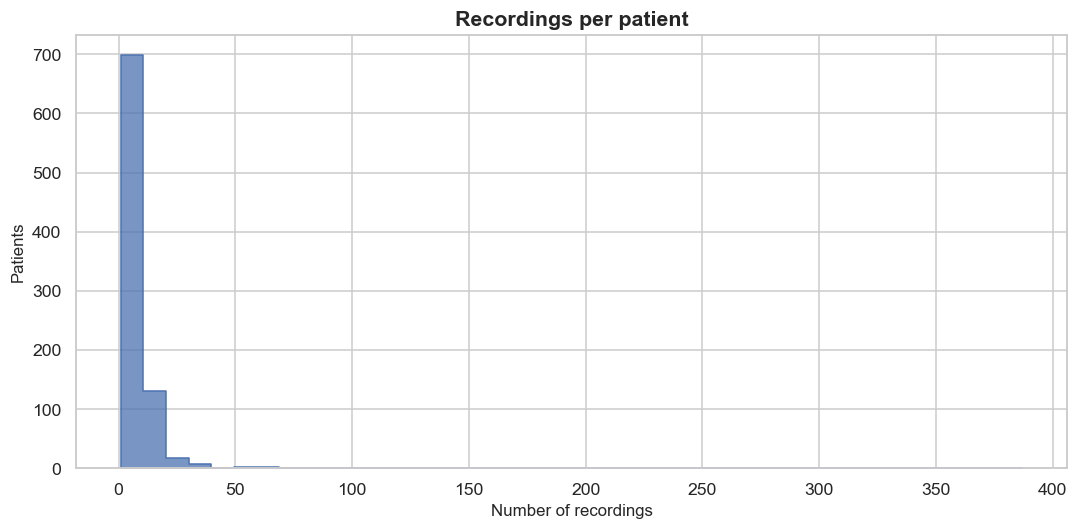

<Axes: title={'center': 'Recordings per patient'}, xlabel='Number of recordings', ylabel='Patients'>

In [28]:
plot_hist(df.groupby("patient_id").size().to_frame("count"), x="count", kde=False, title="Recordings per patient", xlabel="Number of recordings", ylabel="Patients", figsize=(10, 5))

In [29]:
train_patients = set(df.loc[df["split"] == "train", "patient_id"].dropna())
test_patients = set(df.loc[df["split"] == "test", "patient_id"].dropna())
overlap = train_patients & test_patients

print(f"Train patients: {len(train_patients)}")
print(f"Test patients: {len(test_patients)}")
print(f"Patients appearing in both: {len(overlap)}")

Train patients: 699
Test patients: 162
Patients appearing in both: 1


## 11. Events analysis
---

In [30]:
event_rows = []
for _, row in df.iterrows():
    for event in row["events"]:
        start, end = event["start_ms"], event["end_ms"]
        if start is None or end is None:
            continue
        event_rows.append({
            "stem": row["stem"], "patient_id": row["patient_id"], "split": row["split"],
            "source": row["source"], "gender": row["gender"], "location": row["location"],
            "class": event["type"], "class_name": CLASS_NAMES.get(event["type"], event["type"]),
            "start_ms": int(start), "end_ms": int(end), "duration_ms": int(end) - int(start),
            "record_duration_s": row["duration_s"],
        })

events_df = pd.DataFrame(event_rows)
print(f"Total events: {len(events_df):,}")
display(events_df.head())

Total events: 24,578


,stem,patient_id,split,source,gender,location,class,class_name,start_ms,end_ms,duration_ms,record_duration_s
0,2022__40138127_14.7_0_p3_139,40138127,train,2022,0,p3,N,Normal,1079,4933,3854,9.216
1,2022__40138127_14.7_0_p4_140,40138127,train,2022,0,p4,N,Normal,4300,7867,3567,9.216
2,2022__40490865_8.4_1_p1_1884,40490865,train,2022,1,p1,N,Normal,2000,3301,1301,9.216
3,2022__40490865_8.4_1_p1_1884,40490865,train,2022,1,p1,N,Normal,3889,5161,1272,9.216
4,2022__40490865_8.4_1_p1_1884,40490865,train,2022,1,p1,N,Normal,6002,7204,1202,9.216


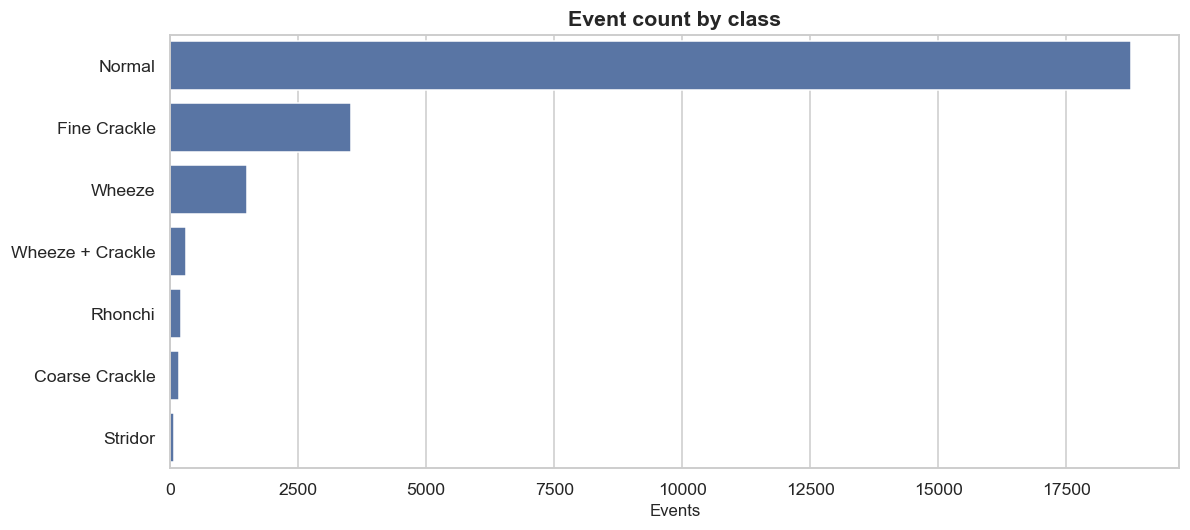

In [31]:
order = events_df["class_name"].value_counts().index
plt.figure(figsize=(11, 5))
sns.countplot(data=events_df, y="class_name", order=order)
plt.title("Event count by class")
plt.xlabel("Events")
plt.ylabel("")
plt.tight_layout()
plt.show()

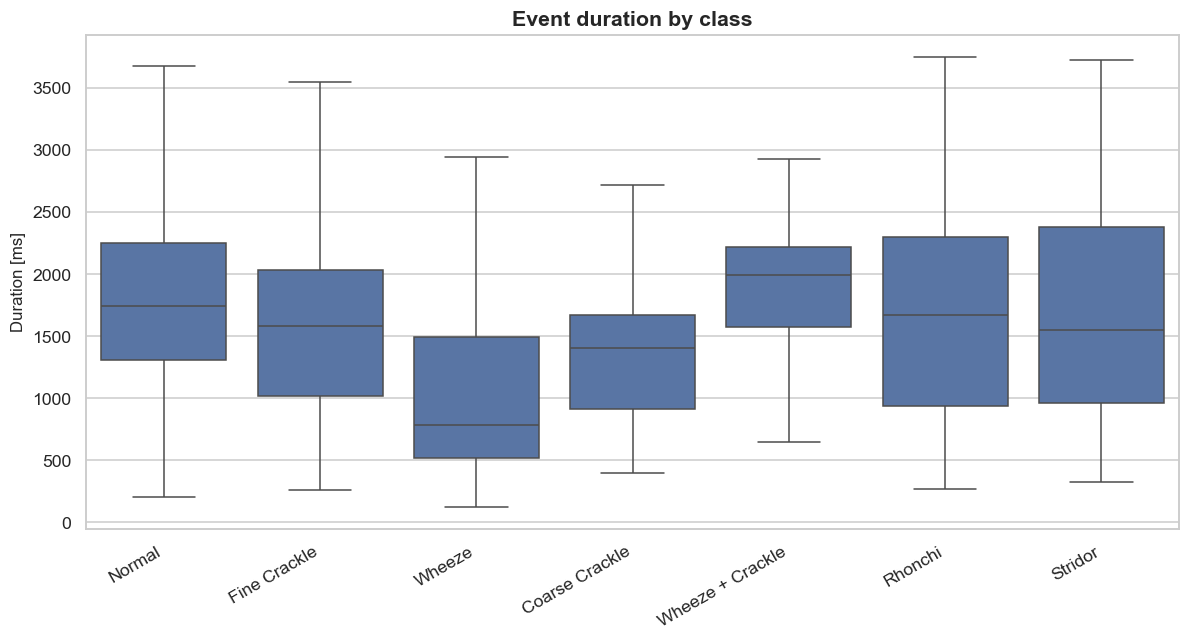

In [32]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=events_df, x="class_name", y="duration_ms", showfliers=False)
plt.title("Event duration by class")
plt.xlabel("")
plt.ylabel("Duration [ms]")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

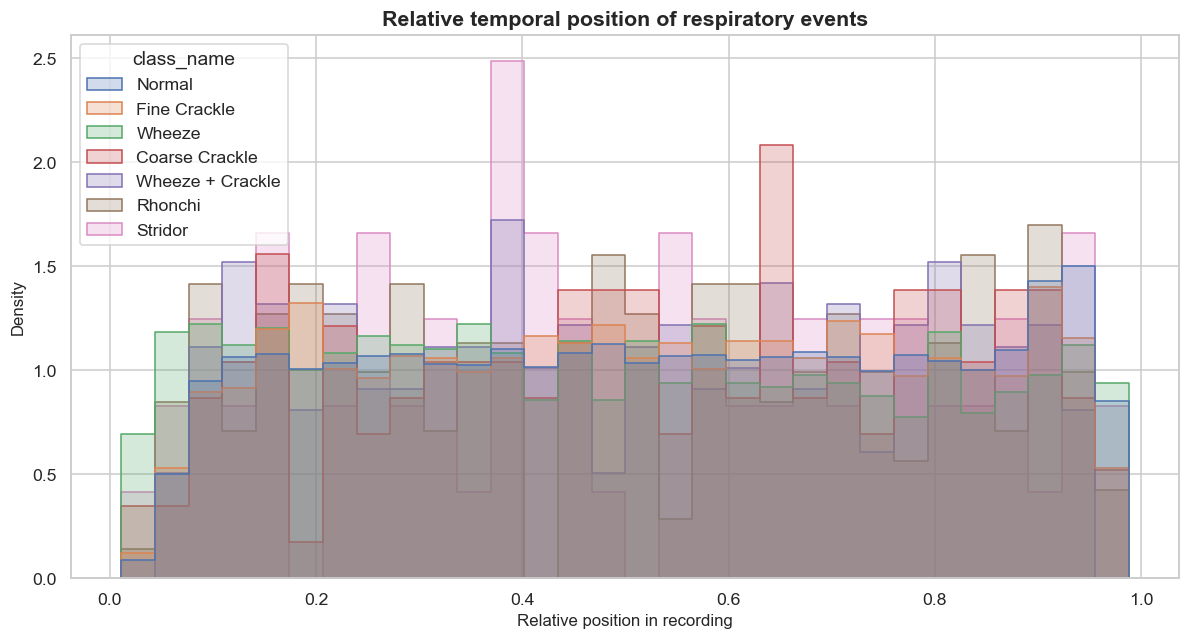

In [33]:
events_df["relative_start"] = events_df["start_ms"] / (events_df["record_duration_s"] * 1000)
events_df["relative_end"] = events_df["end_ms"] / (events_df["record_duration_s"] * 1000)
events_df["relative_center"] = (events_df["relative_start"] + events_df["relative_end"]) / 2

plt.figure(figsize=(11, 6))
sns.histplot(
    data=events_df, x="relative_center", hue="class_name",
    bins=30, element="step", stat="density", common_norm=False,
)
plt.title("Relative temporal position of respiratory events")
plt.xlabel("Relative position in recording")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

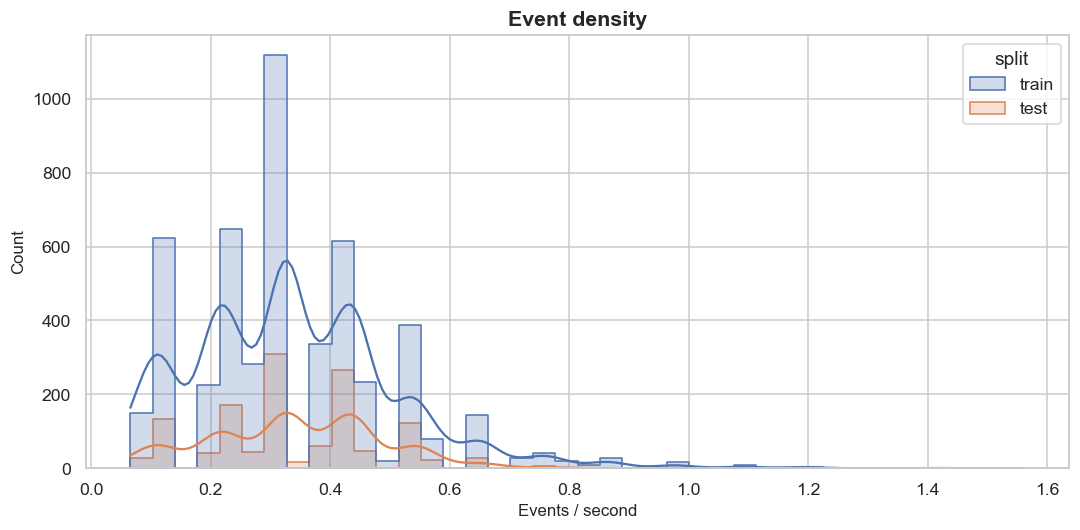

<Axes: title={'center': 'Event density'}, xlabel='Events / second', ylabel='Count'>

In [34]:
event_density = events_df.groupby("stem").size().rename("event_count")
df = df.join(event_density, on="stem")
df["event_count"] = df["event_count"].fillna(0)
df["event_density"] = df["event_count"] / df["duration_s"]

plot_hist(df, x="event_density", hue="split", title="Event density", xlabel="Events / second")

## 12. Events acoustic features
---

In [35]:
segment_rows = []
for _, row in df.iterrows():
    for idx, event in enumerate(row["events"]):
        start_ms, end_ms = event["start_ms"], event["end_ms"]
        if start_ms is None or end_ms is None or end_ms <= start_ms:
            continue

        segment_rows.append({
            "segment_id": f"{row['stem']}_{idx}",
            "stem": row["stem"], "wav_path": row["wav_path"],
            "split": row["split"], "source": row["source"],
            "patient_id": row["patient_id"], "gender": row["gender"], "location": row["location"],
            "event_idx": idx, "class": event["type"],
            "start_ms": int(start_ms), "end_ms": int(end_ms),
            "duration_ms": int(end_ms) - int(start_ms),
            # Duracion de la GRABACION completa, no del segmento: necesaria mas
            # abajo para calcular la posicion relativa correctamente.
            "record_duration_s": row["duration_s"],
        })

segments_df = pd.DataFrame(segment_rows)
print(f"Total segments: {len(segments_df):,}")
display(segments_df.head())

Total segments: 20,578


,segment_id,stem,wav_path,split,source,patient_id,gender,location,event_idx,class,start_ms,end_ms,duration_ms,record_duration_s
0,2022__40138127_14.7_0_p3_139_0,2022__40138127_14.7_0_p3_139,..\data\raw_data\train\wav\2022__40138127_14.7...,train,2022,40138127,0,p3,0,N,1079,4933,3854,9.216
1,2022__40138127_14.7_0_p4_140_0,2022__40138127_14.7_0_p4_140,..\data\raw_data\train\wav\2022__40138127_14.7...,train,2022,40138127,0,p4,0,N,4300,7867,3567,9.216
2,2022__40490865_8.4_1_p1_1884_0,2022__40490865_8.4_1_p1_1884,..\data\raw_data\train\wav\2022__40490865_8.4_...,train,2022,40490865,1,p1,0,N,2000,3301,1301,9.216
3,2022__40490865_8.4_1_p1_1884_1,2022__40490865_8.4_1_p1_1884,..\data\raw_data\train\wav\2022__40490865_8.4_...,train,2022,40490865,1,p1,1,N,3889,5161,1272,9.216
4,2022__40490865_8.4_1_p1_1884_2,2022__40490865_8.4_1_p1_1884,..\data\raw_data\train\wav\2022__40490865_8.4_...,train,2022,40490865,1,p1,2,N,6002,7204,1202,9.216


In [36]:
def tonal_features(x_tensor, sr, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """
    Tonalidad: separa sonidos tonales (sibilancias, estridor) de sonidos de
    banda ancha (crepitantes, ruido respiratorio normal).
    """
    spec = torch.stft(x_tensor, n_fft=n_fft, hop_length=hop_length, win_length=n_fft, return_complex=True)
    power = spec.abs() ** 2  # [freq, time]
    freqs = torch.fft.rfftfreq(n_fft, d=1 / sr).to(power.device)
    eps = 1e-12

    # Spectral flatness (Wiener entropy): ~0 tonal, ~1 ruido banda ancha
    geo_mean = torch.exp(torch.log(power + eps).mean(dim=0))
    arith_mean = power.mean(dim=0) + eps
    spectral_flatness = (geo_mean / arith_mean).mean().item()

    # Estabilidad del pico dominante entre frames: baja std = tono estable
    peak_freqs = freqs[power.argmax(dim=0)]
    peak_freq_std = peak_freqs.std().item() if peak_freqs.numel() > 1 else 0.0

    # Energia concentrada alrededor del pico dominante promedio vs. total
    mean_spectrum = power.mean(dim=1)
    dominant_freq = freqs[mean_spectrum.argmax()]
    band_mask = (freqs >= dominant_freq - 50) & (freqs <= dominant_freq + 50)
    tonal_energy = mean_spectrum[band_mask].sum()
    total_energy = mean_spectrum.sum() + eps

    return {
        "spectral_flatness": spectral_flatness,
        "peak_freq_std": peak_freq_std,
        "tonal_energy_ratio": (tonal_energy / total_energy).item(),
    }


def transient_features(x_np, sr, frame_ms=2, hop_ms=1):
    """
    Transitorios: los crepitantes son eventos cortos (5-20ms) de banda ancha.
    Se detectan como picos en la envolvente de energia de corto plazo, en vez
    de usar estadisticos globales del segmento completo.
    """
    frame_len = max(int(sr * frame_ms / 1000), 1)
    hop_len = max(int(sr * hop_ms / 1000), 1)
    n = len(x_np)
    n_frames = max((n - frame_len) // hop_len + 1, 1)

    envelope = np.array([
        np.sqrt(np.mean(x_np[i * hop_len: i * hop_len + frame_len] ** 2))
        for i in range(n_frames)
    ])

    if len(envelope) < 3:
        return {"n_transients": 0, "transient_rate": 0.0, "envelope_kurtosis": 0.0}

    threshold = envelope.mean() + envelope.std()
    peaks = (
        (envelope[1:-1] > envelope[:-2]) &
        (envelope[1:-1] > envelope[2:]) &
        (envelope[1:-1] > threshold)
    )
    n_transients = int(peaks.sum())
    duration_s = n / sr

    return {
        "n_transients": n_transients,
        "transient_rate": n_transients / duration_s if duration_s > 0 else 0.0,
        "envelope_kurtosis": float(kurtosis(envelope)),
    }


# pip install PyWavelets  (si no lo tenes instalado)
import pywt

def wavelet_features(x_np, wavelet="db4", level=4):
    """
    DWT: tecnica estandar en literatura de deteccion de crepitantes. Los
    coeficientes de detalle de alta resolucion capturan mejor energia de
    eventos transitorios de banda ancha que la STFT.
    """
    max_level = pywt.dwt_max_level(len(x_np), pywt.Wavelet(wavelet).dec_len)
    level = min(level, max_level) if max_level > 0 else 1

    coeffs = pywt.wavedec(x_np, wavelet=wavelet, level=level)
    energies = np.array([np.sum(c ** 2) for c in coeffs])
    relative = energies / (energies.sum() + 1e-12)

    features = {"wavelet_approx_energy": float(relative[0])}
    for i, e in enumerate(relative[1:], start=1):
        features[f"wavelet_detail_{i}_energy"] = float(e)
    return features


N_MFCC = 13

mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=TARGET_SR,
    n_mfcc=N_MFCC,
    melkwargs={"n_fft": N_FFT, "hop_length": HOP_LENGTH, "n_mels": 40},
)

def mfcc_features(waveform, sr):
    """
    MFCC + delta + delta-delta, resumidos con media/std sobre el tiempo.
    Estandar en clasificacion de sonidos respiratorios (ICBHI, HF-Lung).
    """
    if sr != TARGET_SR:
        waveform = torchaudio.functional.resample(waveform, sr, TARGET_SR)

    mfcc = mfcc_transform(waveform)
    delta = torchaudio.functional.compute_deltas(mfcc)
    delta2 = torchaudio.functional.compute_deltas(delta)

    features = {}
    for name, tensor in [("mfcc", mfcc), ("mfcc_delta", delta), ("mfcc_delta2", delta2)]:
        stats = tensor.squeeze(0)
        for i in range(stats.shape[0]):
            features[f"{name}_{i}_mean"] = stats[i].mean().item()
            features[f"{name}_{i}_std"] = stats[i].std().item()
    return features

In [37]:
def load_segment(path, start_ms, end_ms):
    """Carga unicamente el segmento anotado."""
    info = AudioDecoder(str(path)).metadata
    sr = info.sample_rate

    start_frame = int(start_ms / 1000 * sr)
    end_frame = int(end_ms / 1000 * sr)

    waveform, sr = torchaudio.load(
        str(path), frame_offset=start_frame, num_frames=end_frame - start_frame,
    )
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    return waveform, sr


def band_energy_features(x_tensor, sr, n_fft=N_FFT, hop_length=HOP_LENGTH):
    spec = torch.stft(x_tensor, n_fft=n_fft, hop_length=hop_length, win_length=n_fft, return_complex=True)
    power = spec.abs() ** 2
    freqs = torch.fft.rfftfreq(n_fft, d=1 / sr).to(power.device)

    mean_power = power.mean(dim=1)
    total_power = mean_power.sum() + 1e-12

    features = {}
    for name, (low, high) in RESPIRATORY_BANDS.items():
        mask = (freqs >= low) & (freqs < high)
        energy = mean_power[mask].sum()
        features[f"{name}_energy"] = energy.item()
        features[f"{name}_relative"] = (energy / total_power).item()

    return features


def spectral_entropy(x_tensor, sr, n_fft=N_FFT, hop_length=HOP_LENGTH):
    spec = torch.stft(x_tensor, n_fft=n_fft, hop_length=hop_length, win_length=n_fft, return_complex=True)
    power = (spec.abs() ** 2).mean(dim=1)
    p = power / (power.sum() + 1e-12)
    return float(-torch.sum(p * torch.log2(p + 1e-12)))


def extract_segment_features(row):
    waveform, sr = load_segment(row["wav_path"], row["start_ms"], row["end_ms"])
    x_np = waveform.squeeze(0).numpy()
    x_tensor = waveform.squeeze(0).to(DEVICE)

    features = amplitude_temporal_features(x_np)
    features.pop("energy")
    features.pop("dynamic_range")

    features.update(spectral_features(x_tensor, sr))
    features["spectral_entropy"] = spectral_entropy(x_tensor, sr)
    features.update(band_energy_features(x_tensor, sr))

    # --- Features especificas de dominio clinico ---
    features.update(tonal_features(x_tensor, sr))
    features.update(transient_features(x_np, sr))
    features.update(wavelet_features(x_np))
    features.update(mfcc_features(waveform, sr))

    return features

In [38]:
segment_features = []
n_errors = 0

for _, row in tqdm(segments_df.iterrows(), total=len(segments_df), desc="Extracting segment-level features"):
    try:
        f = extract_segment_features(row)
        segment_features.append({"segment_id": row["segment_id"], **f})
    except Exception as e:
        n_errors += 1

if n_errors:
    print(f"{n_errors} segments failed feature extraction (skipped).")

features_df = pd.DataFrame(segment_features)
segments_df = segments_df.merge(features_df, on="segment_id", how="left")

print(segments_df.shape)
display(segments_df.head())

Extracting segment-level features:   0%|          | 0/20578 [00:00<?, ?it/s]

1 segments failed feature extraction (skipped).
(20578, 126)


,segment_id,stem,wav_path,split,source,patient_id,gender,location,event_idx,class,...,mfcc_delta2_8_mean,mfcc_delta2_8_std,mfcc_delta2_9_mean,mfcc_delta2_9_std,mfcc_delta2_10_mean,mfcc_delta2_10_std,mfcc_delta2_11_mean,mfcc_delta2_11_std,mfcc_delta2_12_mean,mfcc_delta2_12_std
0,2022__40138127_14.7_0_p3_139_0,2022__40138127_14.7_0_p3_139,..\data\raw_data\train\wav\2022__40138127_14.7...,train,2022,40138127,0,p3,0,N,...,0.006242,0.351232,-0.006266,0.368468,0.030206,0.455416,0.001512,0.230272,0.002704,0.352004
1,2022__40138127_14.7_0_p4_140_0,2022__40138127_14.7_0_p4_140,..\data\raw_data\train\wav\2022__40138127_14.7...,train,2022,40138127,0,p4,0,N,...,0.029055,0.358006,0.016729,0.418155,0.011269,0.524004,0.018557,0.329136,0.025695,0.411826
2,2022__40490865_8.4_1_p1_1884_0,2022__40490865_8.4_1_p1_1884,..\data\raw_data\train\wav\2022__40490865_8.4_...,train,2022,40490865,1,p1,0,N,...,-0.115428,0.343013,-0.148604,0.688348,0.017838,0.399301,-0.057875,0.475444,-0.058610,0.448946
3,2022__40490865_8.4_1_p1_1884_1,2022__40490865_8.4_1_p1_1884,..\data\raw_data\train\wav\2022__40490865_8.4_...,train,2022,40490865,1,p1,1,N,...,-0.066424,0.459102,-0.114118,0.268833,-0.053790,0.201843,-0.014524,0.393520,0.024092,0.319630
4,2022__40490865_8.4_1_p1_1884_2,2022__40490865_8.4_1_p1_1884,..\data\raw_data\train\wav\2022__40490865_8.4_...,train,2022,40490865,1,p1,2,N,...,0.052354,0.413200,-0.003567,0.511389,0.029735,0.354467,-0.041402,0.378982,0.046461,0.315298


### Event's length and position

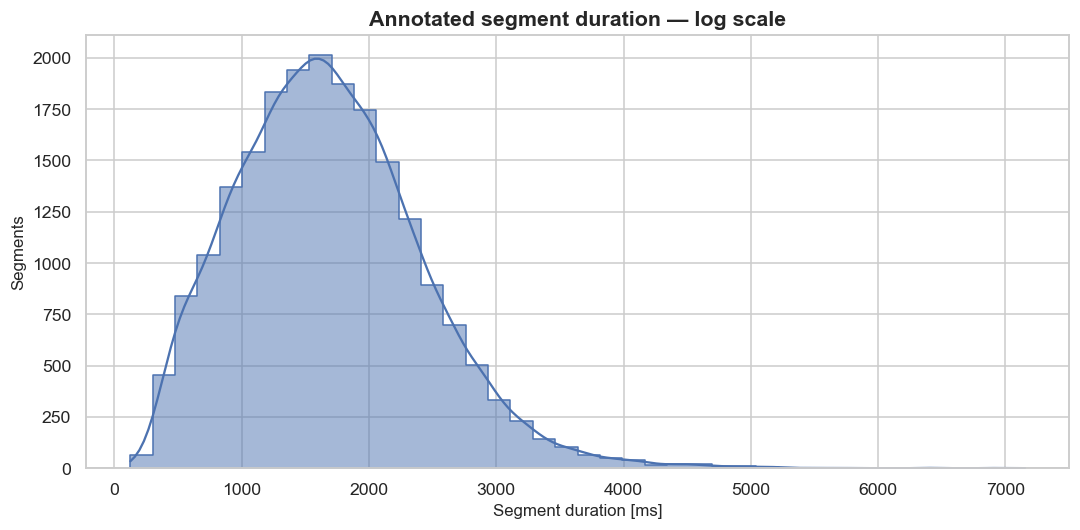

<Axes: title={'center': 'Annotated segment duration — log scale'}, xlabel='Segment duration [ms]', ylabel='Segments'>

In [73]:
plot_hist(segments_df, x="duration_ms", kde=True, log_scale=False, title="Annotated segment duration — log scale", xlabel="Segment duration [ms]", ylabel="Segments")

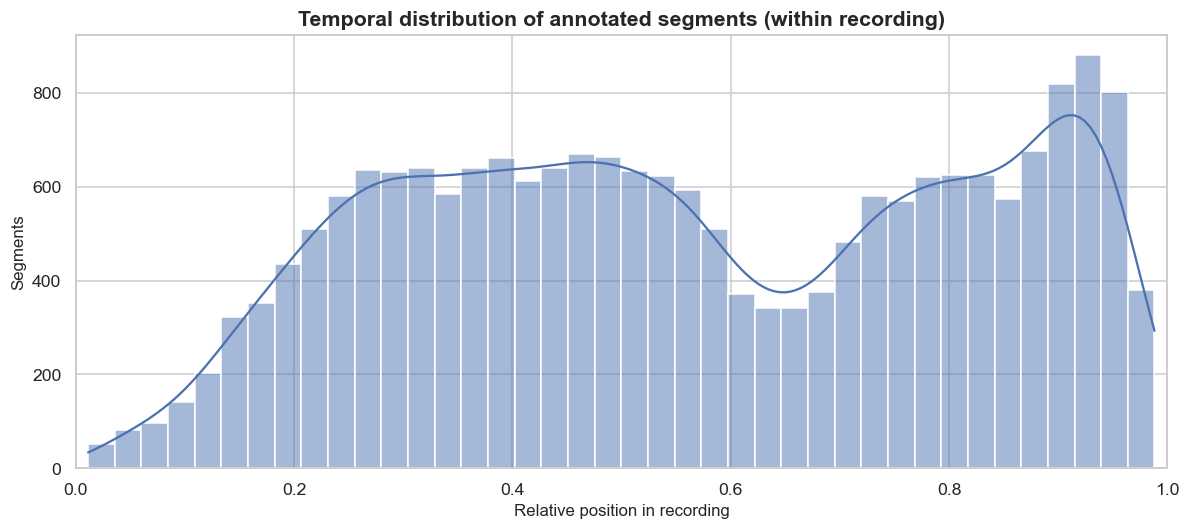

In [40]:
# BUG corregido: el notebook original dividia por la duracion del propio
# segmento (`duration_ms`) en vez de la duracion de la grabacion completa,
# lo que producia valores de posicion relativa sin sentido (no acotados a [0, 1]).
segments_df["relative_start"] = segments_df["start_ms"] / (segments_df["record_duration_s"] * 1000)
segments_df["relative_end"] = segments_df["end_ms"] / (segments_df["record_duration_s"] * 1000)
segments_df["relative_center"] = (segments_df["relative_start"] + segments_df["relative_end"]) / 2

plt.figure(figsize=(11, 5))
sns.histplot(data=segments_df, x="relative_center", bins=40, kde=True)
plt.title("Temporal distribution of annotated segments (within recording)")
plt.xlabel("Relative position in recording")
plt.ylabel("Segments")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

### Acoustic features by class

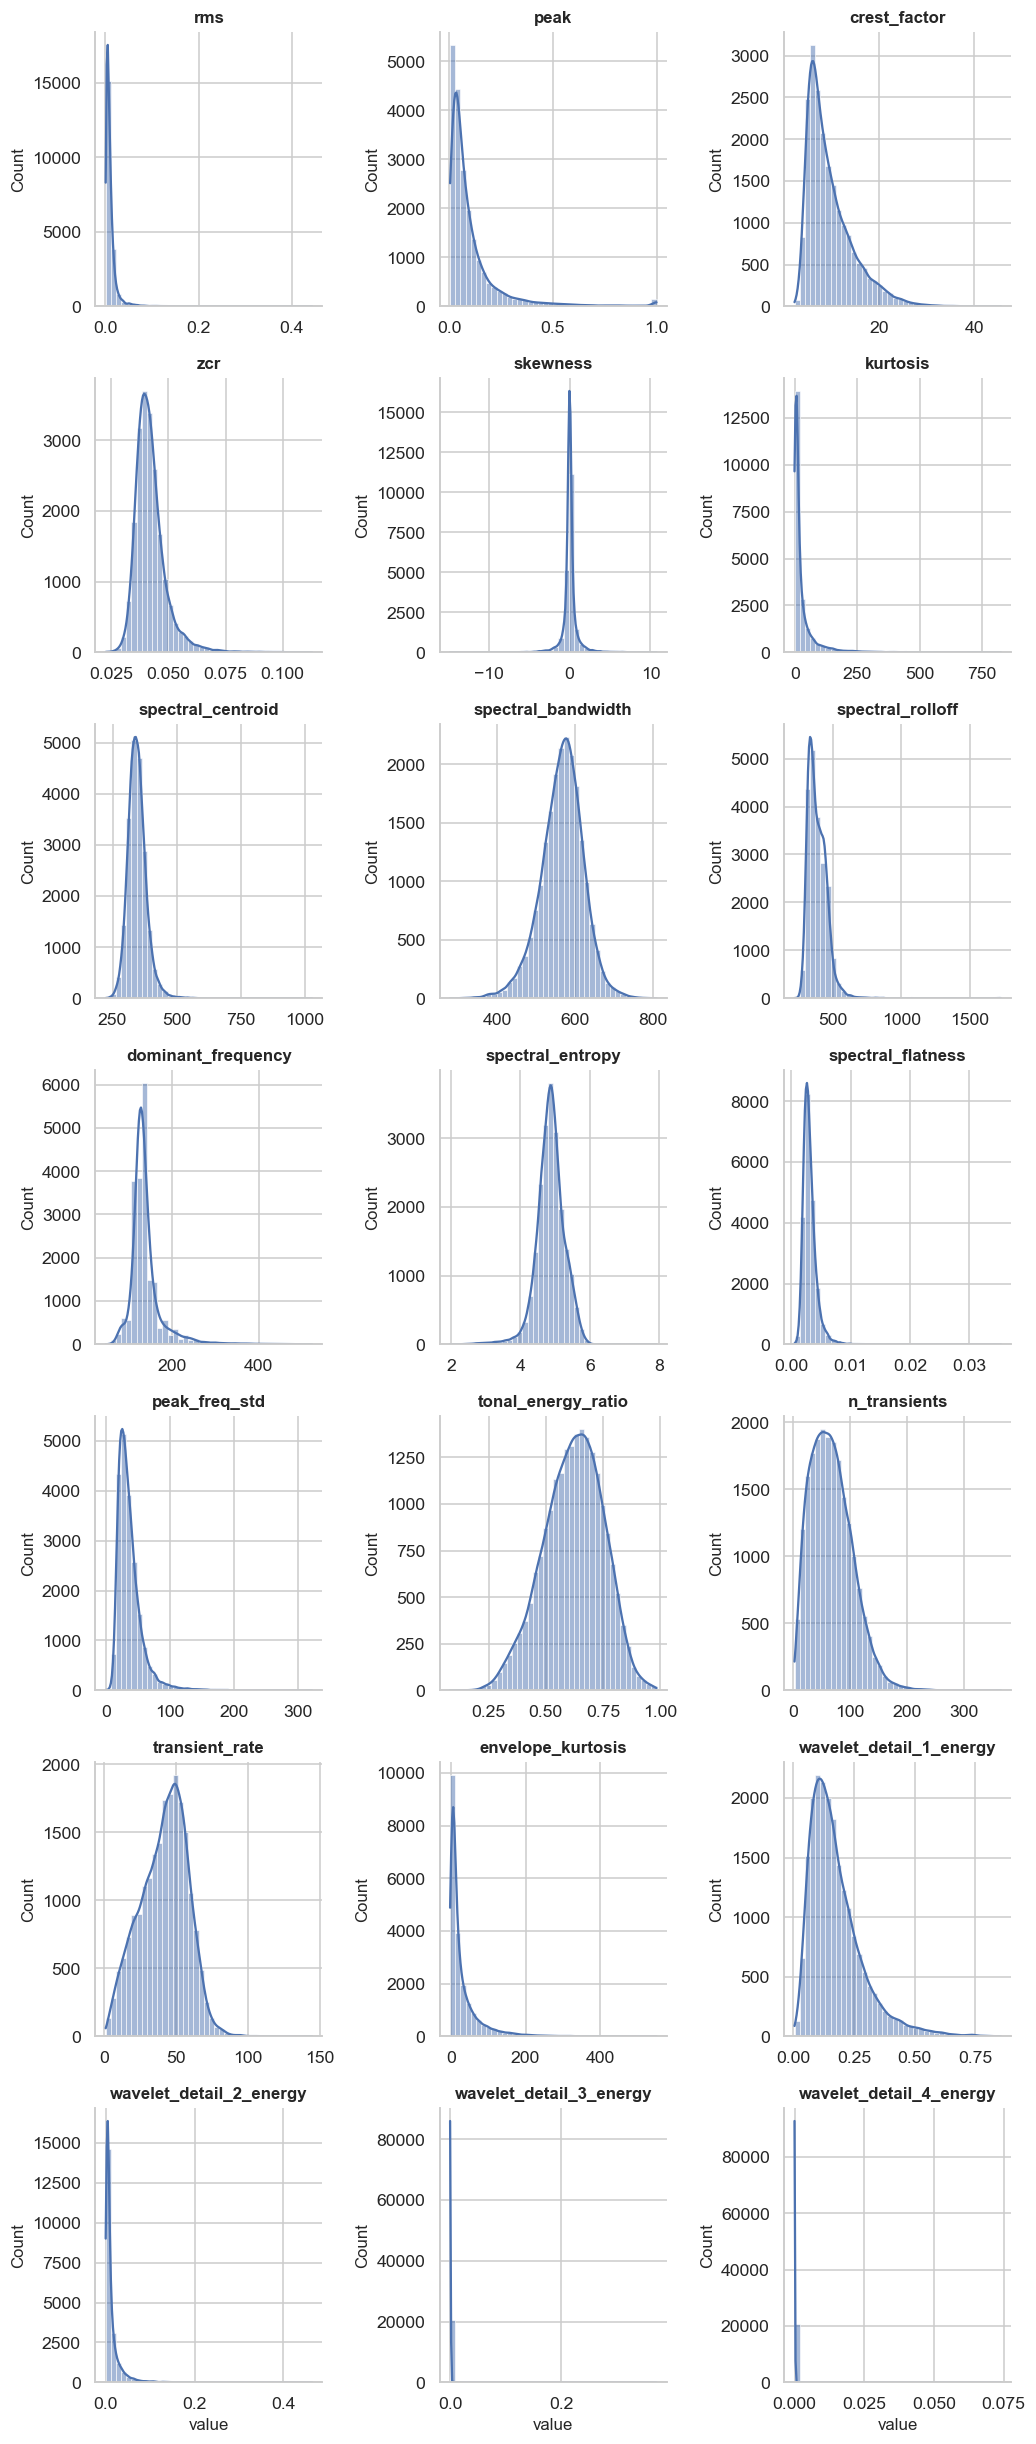

In [41]:
SEGMENT_FEATURES = [
    "rms", "peak", "crest_factor", "zcr", "skewness", "kurtosis",
    "spectral_centroid", "spectral_bandwidth", "spectral_rolloff",
    "dominant_frequency", "spectral_entropy",
    "spectral_flatness", "peak_freq_std", "tonal_energy_ratio",
    "n_transients", "transient_rate", "envelope_kurtosis",
    "wavelet_detail_1_energy", "wavelet_detail_2_energy",
    "wavelet_detail_3_energy", "wavelet_detail_4_energy",
]

# Todas las features numericas (incluye MFCCs) para PCA/UMAP/clustering
EXCLUDE_COLS = {
    "segment_id", "stem", "wav_path", "split", "source", "patient_id",
    "gender", "location", "event_idx", "class", "start_ms", "end_ms",
    "duration_ms", "record_duration_s",
}
ALL_SEGMENT_FEATURES = [
    c for c in segments_df.columns
    if c not in EXCLUDE_COLS and pd.api.types.is_numeric_dtype(segments_df[c])
]

long_df = segments_df[SEGMENT_FEATURES].melt(var_name="feature", value_name="value")
g = sns.FacetGrid(long_df, col="feature", col_wrap=3, height=3.2, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x="value", bins=40, kde=True)
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

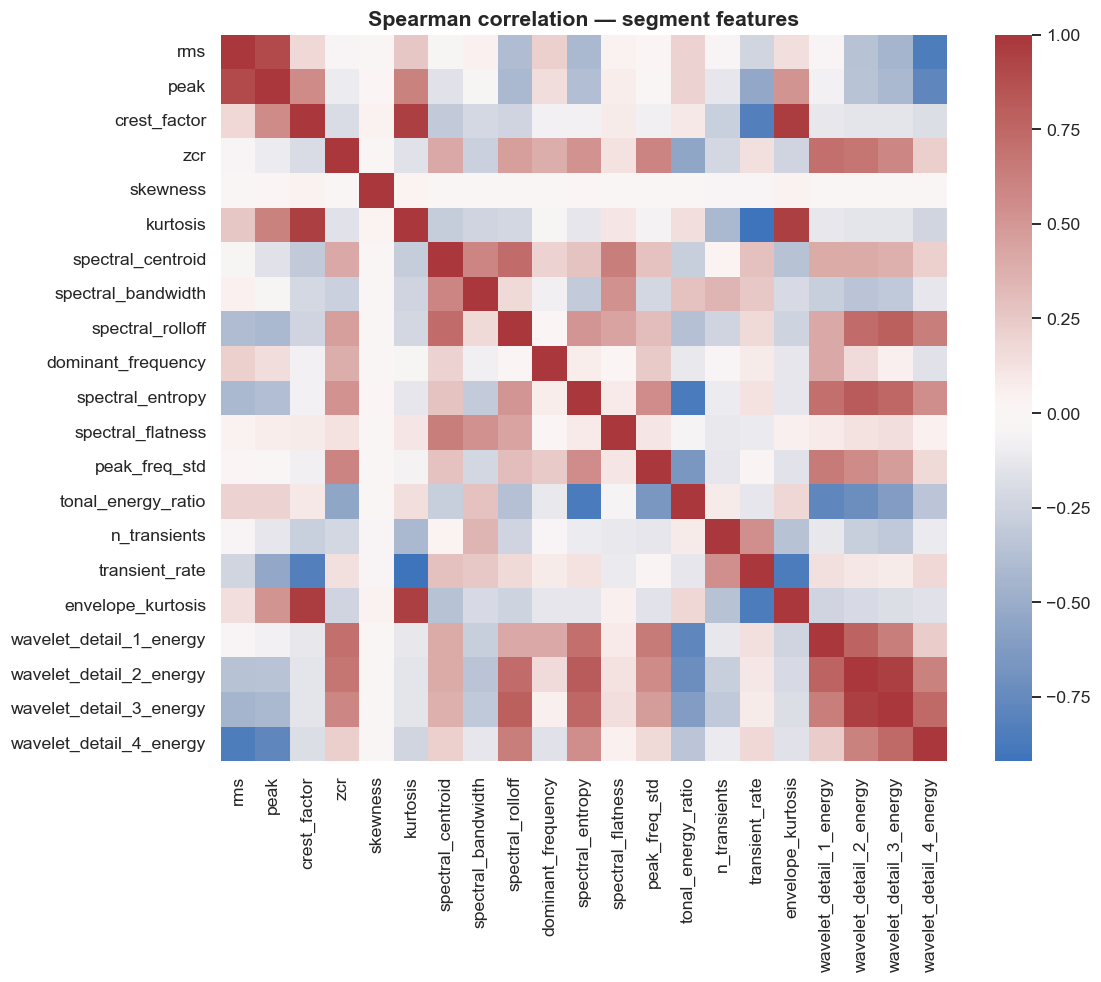

In [42]:
corr = segments_df[SEGMENT_FEATURES].corr(method="spearman")
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="vlag", center=0, square=True)
plt.title("Spearman correlation — segment features")
plt.tight_layout()
plt.show()

### PCA / UMAP - Segments

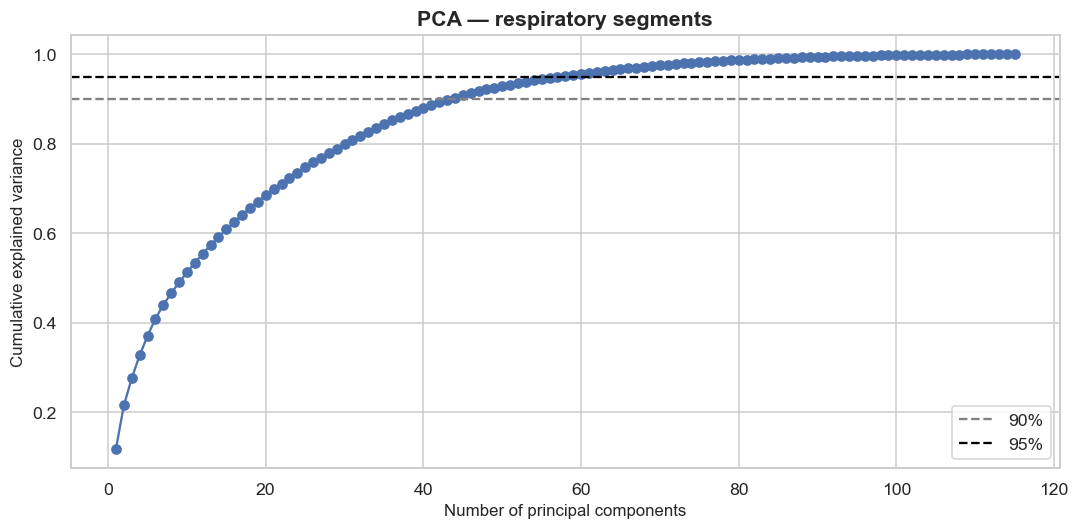

In [43]:
X_scaled_seg, pca_seg, X_pca_seg, X_umap_seg = scale_and_reduce(
    segments_df[ALL_SEGMENT_FEATURES], metric="cosine"
)

segments_plot = segments_df.copy()
segments_plot["UMAP1"], segments_plot["UMAP2"] = X_umap_seg[:, 0], X_umap_seg[:, 1]
segments_plot["class_name"] = segments_plot["class"].map(CLASS_NAMES).fillna(segments_plot["class"])

plot_pca_variance(pca_seg, title="PCA — respiratory segments")

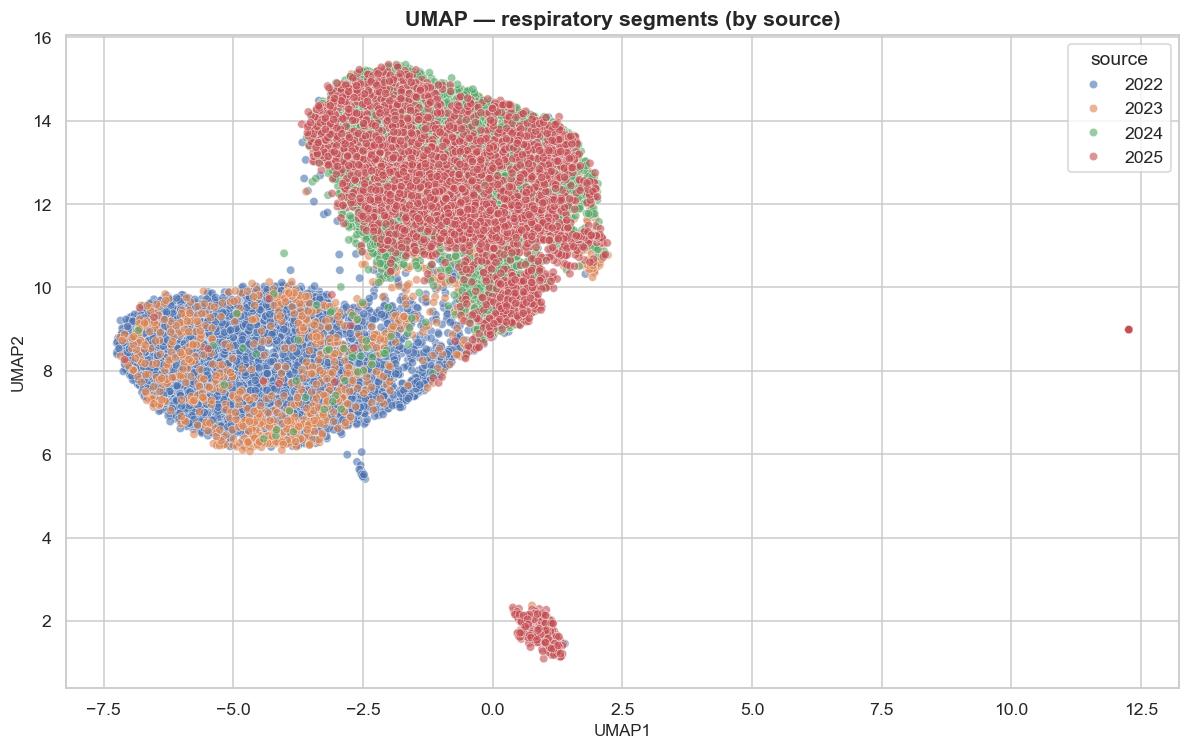

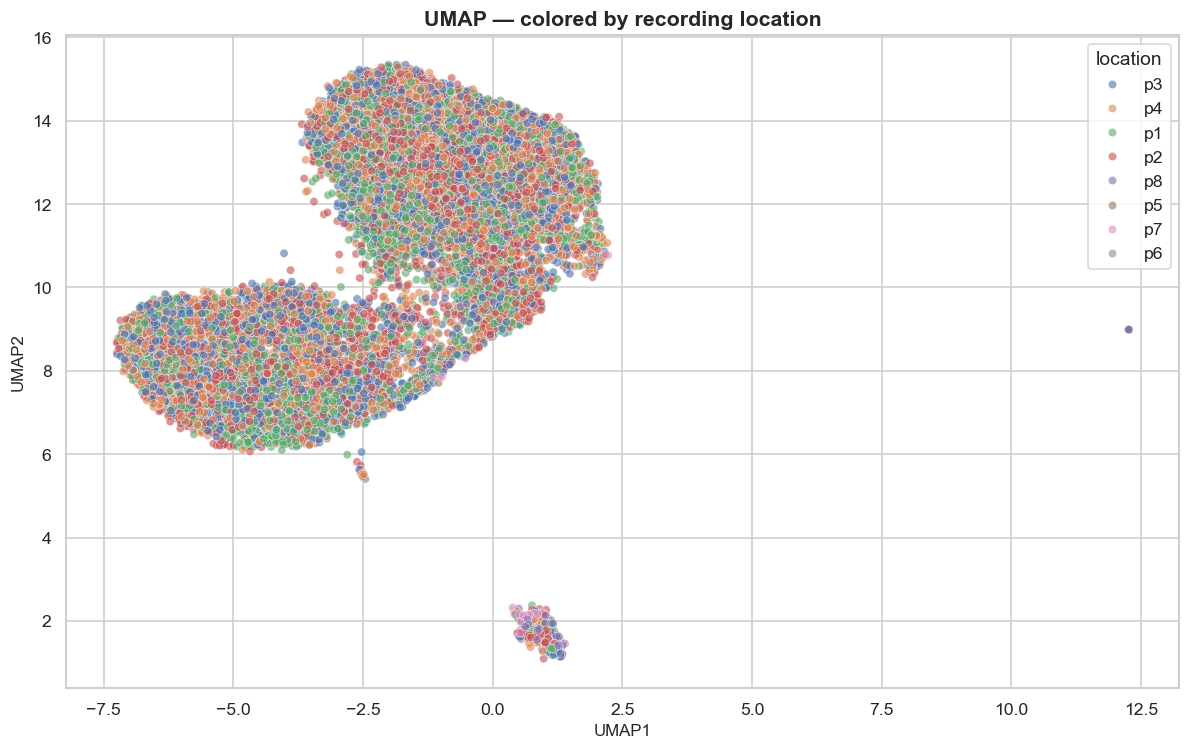

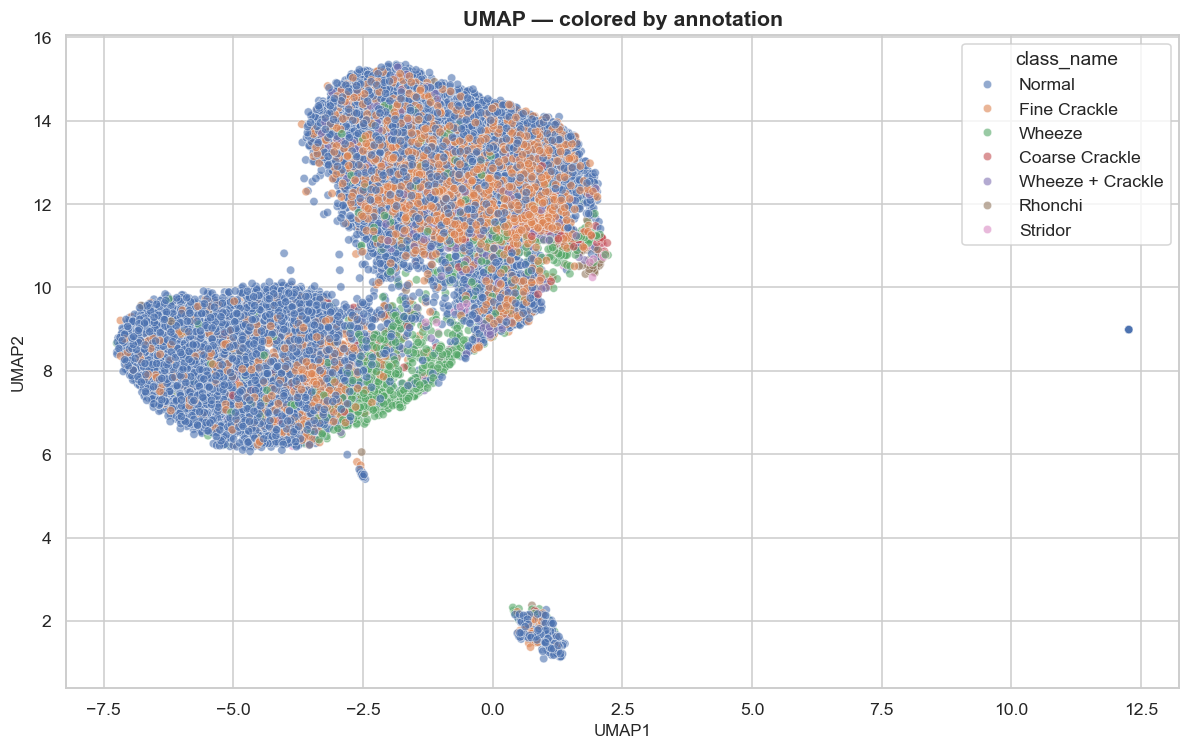

In [44]:
plot_scatter_2d(segments_plot, x="UMAP1", y="UMAP2", hue="source", title="UMAP — respiratory segments (by source)", s=30)
plot_scatter_2d(segments_plot, x="UMAP1", y="UMAP2", hue="location", title="UMAP — colored by recording location", s=30)
plot_scatter_2d(segments_plot, x="UMAP1", y="UMAP2", hue="class_name", title="UMAP — colored by annotation", s=30)

In [45]:
def balanced_segment_sample(df, class_col="class", majority_class="N", random_state=RANDOM_STATE):
    """Undersamplea la clase mayoritaria (Normal) al tamano de la segunda
    clase mas grande, para que no domine visualmente la proyeccion UMAP."""
    counts = df[class_col].value_counts()
    cap = counts.drop(index=majority_class, errors="ignore").max()

    parts = []
    for cls, group in df.groupby(class_col):
        if cls == majority_class and len(group) > cap:
            group = group.sample(int(cap), random_state=random_state)
        parts.append(group)

    return pd.concat(parts).reset_index(drop=True)

class
FC    3027
N     3027
W     1312
WC     241
R      175
CC     156
S       58
Name: count, dtype: int64


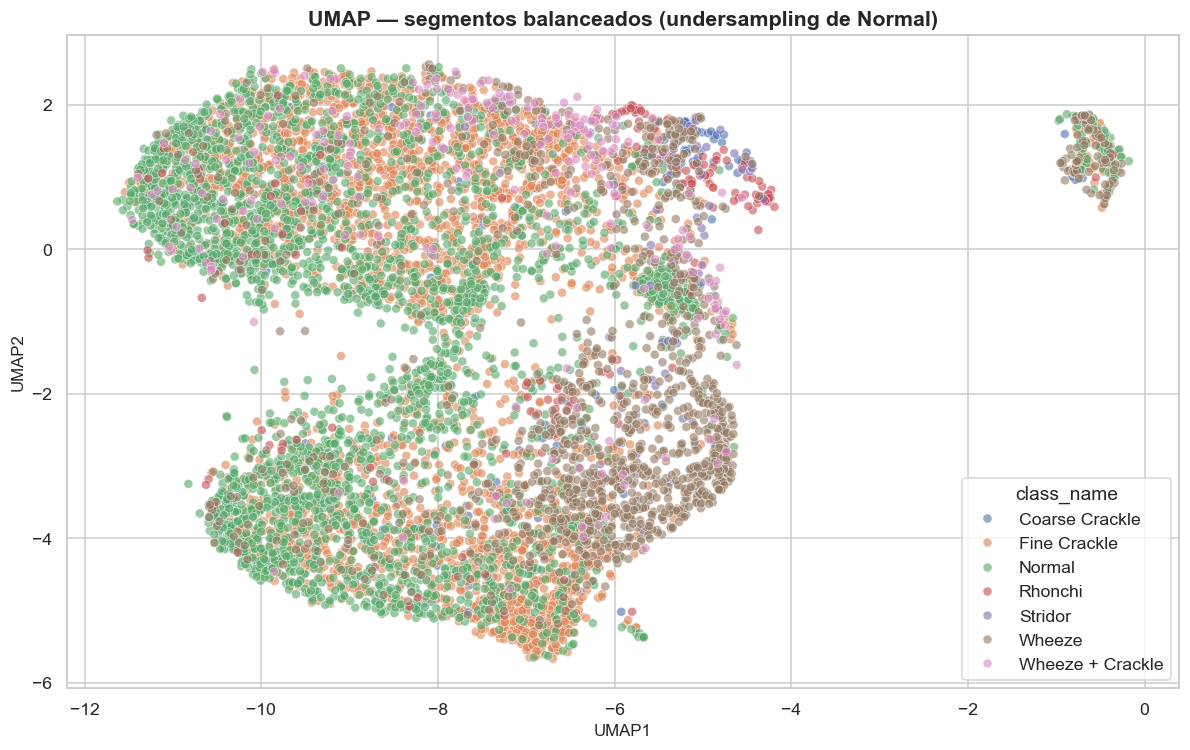

In [46]:
balanced_segments = balanced_segment_sample(segments_df)
print(balanced_segments["class"].value_counts())

X_scaled_bal, pca_bal, X_pca_bal, X_umap_bal = scale_and_reduce(
    balanced_segments[ALL_SEGMENT_FEATURES], metric="cosine"
)

balanced_segments_plot = balanced_segments.copy()
balanced_segments_plot["UMAP1"] = X_umap_bal[:, 0]
balanced_segments_plot["UMAP2"] = X_umap_bal[:, 1]
balanced_segments_plot["class_name"] = (
    balanced_segments_plot["class"].map(CLASS_NAMES).fillna(balanced_segments_plot["class"])
)

plot_scatter_2d(
    balanced_segments_plot, x="UMAP1", y="UMAP2", hue="class_name",
    title="UMAP — segmentos balanceados (undersampling de Normal)", s=35,
)

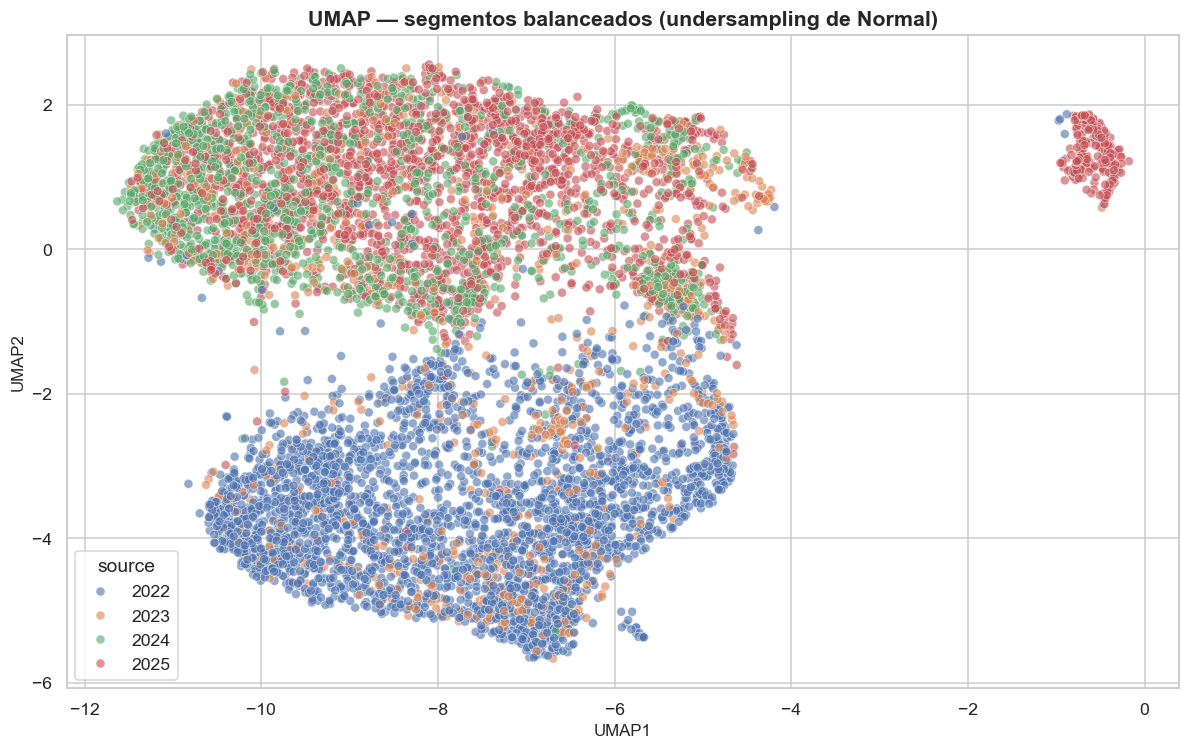

In [47]:
plot_scatter_2d(
    balanced_segments_plot, x="UMAP1", y="UMAP2", hue="source",
    title="UMAP — segmentos balanceados (undersampling de Normal)", s=35,
)

# Small classifiers of segments

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

# Dataset de trabajo: solo segmentos con features validas y clase conocida
clf_df = segments_df.dropna(subset=ALL_SEGMENT_FEATURES, how="all").copy()
clf_df = clf_df[clf_df["class"].isin(CLASS_NAMES.keys())].reset_index(drop=True)

imputer_clf = SimpleImputer(strategy="median")
X_all = imputer_clf.fit_transform(clf_df[ALL_SEGMENT_FEATURES].replace([np.inf, -np.inf], np.nan))
groups_all = clf_df["patient_id"].values

# Usamos el split train/test original del dataset (ya verificamos que no comparte pacientes)
is_train = (clf_df["split"] == "train").values

print(f"Segmentos totales: {len(clf_df):,} | train: {is_train.sum():,} | test: {(~is_train).sum():,}")

Segmentos totales: 20,578 | train: 16,639 | test: 3,939


## Normal vs abnormal

In [53]:
# Balance real del dataset (a nivel de segmento, respetando train/test)
print("=== Distribucion Normal vs Anormal ===")
print(clf_df.groupby("split")["class"].apply(lambda s: (s != "N").value_counts(normalize=True).round(3)))
print()
print(clf_df.groupby("split")["class"].apply(lambda s: (s != "N").value_counts()))

=== Distribucion Normal vs Anormal ===
split       
test   True     0.533
       False    0.467
train  False    0.828
       True     0.172
Name: class, dtype: float64

split       
test   True      2100
       False     1839
train  False    13770
       True      2869
Name: class, dtype: int64


In [50]:
y_binary = (clf_df["class"] != "N").astype(int).values  # 1 = anormal

X_train, X_test = X_all[is_train], X_all[~is_train]
y_train_bin, y_test_bin = y_binary[is_train], y_binary[~is_train]
groups_train = groups_all[is_train]

# CV interna agrupada por paciente sobre el set de train, para tener una
# estimacion honesta antes de tocar el test.
gkf = GroupKFold(n_splits=5)
clf_bin = RandomForestClassifier(
    n_estimators=400, max_depth=None, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1,
)

oof_pred = cross_val_predict(clf_bin, X_train, y_train_bin, cv=gkf, groups=groups_train, n_jobs=-1)

print("=== CV interna (train, GroupKFold por paciente) ===")
print(classification_report(y_train_bin, oof_pred, target_names=["Normal", "Anormal"]))
print("F1 macro (CV):", round(f1_score(y_train_bin, oof_pred, average="macro"), 4))

=== CV interna (train, GroupKFold por paciente) ===
              precision    recall  f1-score   support

      Normal       0.92      0.94      0.93     13770
     Anormal       0.69      0.62      0.66      2869

    accuracy                           0.89     16639
   macro avg       0.81      0.78      0.79     16639
weighted avg       0.88      0.89      0.88     16639

F1 macro (CV): 0.7939


=== Evaluacion en test (pacientes no vistos) ===
              precision    recall  f1-score   support

      Normal       0.49      0.97      0.65      1839
     Anormal       0.82      0.13      0.23      2100

    accuracy                           0.52      3939
   macro avg       0.66      0.55      0.44      3939
weighted avg       0.67      0.52      0.43      3939

F1 macro (test): 0.4417


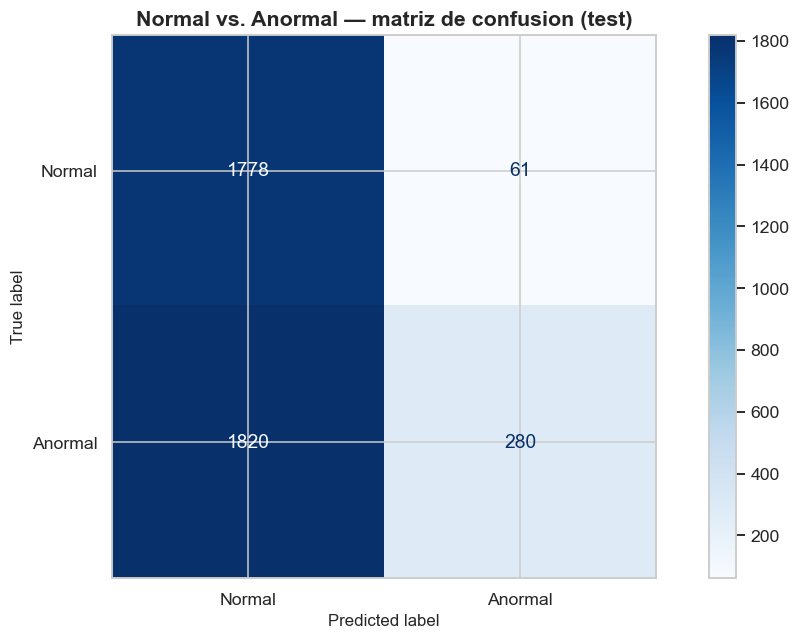

In [51]:
# Entrenamiento final sobre todo train, evaluacion sobre test (pacientes nunca vistos)
clf_bin.fit(X_train, y_train_bin)
test_pred_bin = clf_bin.predict(X_test)

print("=== Evaluacion en test (pacientes no vistos) ===")
print(classification_report(y_test_bin, test_pred_bin, target_names=["Normal", "Anormal"]))
print("F1 macro (test):", round(f1_score(y_test_bin, test_pred_bin, average="macro"), 4))

cm = confusion_matrix(y_test_bin, test_pred_bin)
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Anormal"]).plot(cmap="Blues")
plt.title("Normal vs. Anormal — matriz de confusion (test)")
plt.tight_layout()
plt.show()

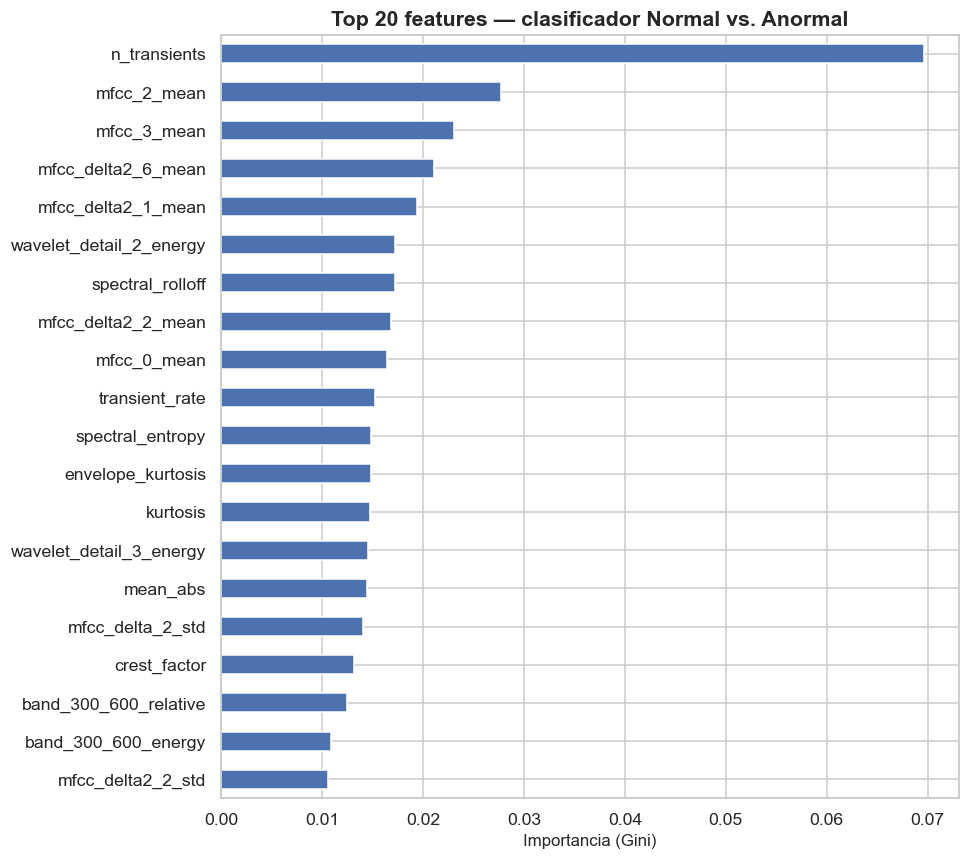

In [52]:
importances = pd.Series(clf_bin.feature_importances_, index=ALL_SEGMENT_FEATURES).sort_values(ascending=False)

plt.figure(figsize=(9, 8))
importances.head(20).sort_values().plot.barh()
plt.title("Top 20 features — clasificador Normal vs. Anormal")
plt.xlabel("Importancia (Gini)")
plt.tight_layout()
plt.show()

In [56]:
# 1. Cross-tab de split vs source: si estan fuertemente correlacionados,
#    train y test podrian venir de equipos/protocolos distintos.
print("=== Distribucion de 'source' por split ===")
print(pd.crosstab(clf_df["split"], clf_df["source"], normalize="index").round(3))
print()
print(pd.crosstab(clf_df["split"], clf_df["source"]))

=== Distribucion de 'source' por split ===
source   2022   2023   2024  2025
split                            
test    0.000  0.000  0.000   1.0
train   0.477  0.155  0.368   0.0

source  2022  2023  2024  2025
split                         
test       0     0     0  3939
train   7935  2582  6122     0


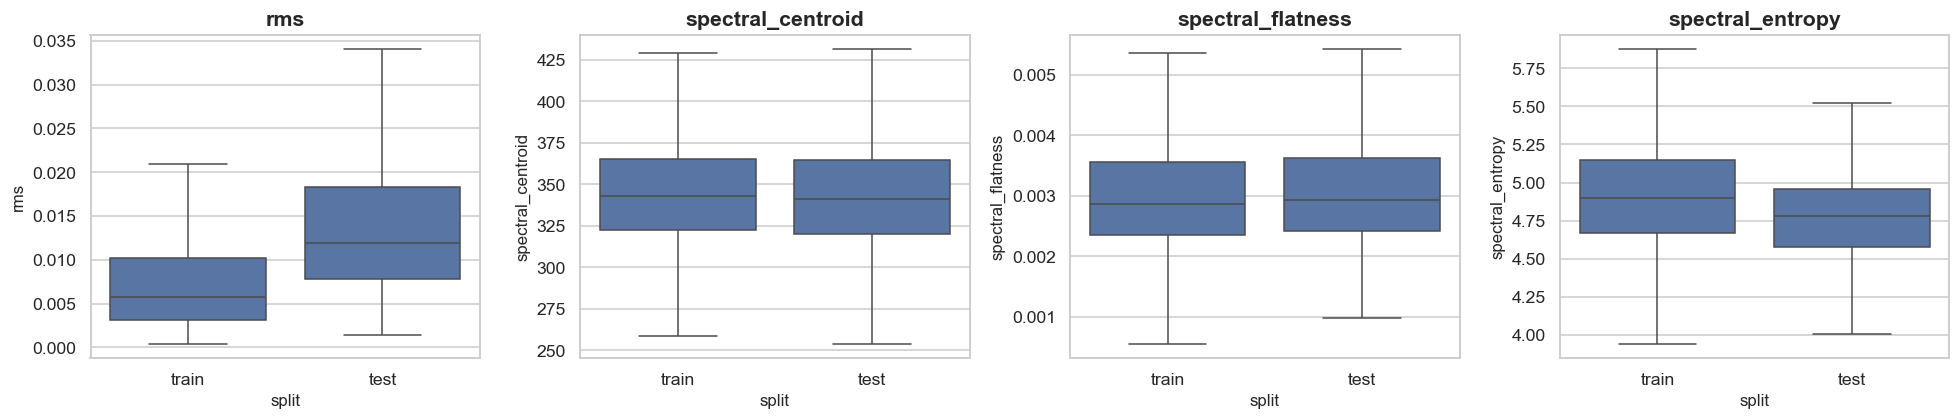

In [65]:
# 2. Comparar distribuciones de features clave entre train y test
#    (no por clase, directamente por split) — si difieren mucho, confirma
#    shift de condiciones de grabacion, no de patologia.
key_features = ["rms", "spectral_centroid", "spectral_flatness", "spectral_entropy"] #"rms_db",

fig, axes = plt.subplots(1, len(key_features), figsize=(18, 4))
for ax, feat in zip(axes, key_features):
    sns.boxplot(data=clf_df, x="split", y=feat, ax=ax, showfliers=False)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

In [63]:
# 3. "Domain classifier": si un modelo puede distinguir train vs test
#    facilmente usando las MISMAS features del clasificador de sintomas,
#    eso demuestra shift de dominio de forma directa (AUC alto = mucho shift,
#    AUC ~0.5 = distribuciones parecidas).
from sklearn.metrics import roc_auc_score

y_domain = is_train.astype(int)  # 1 = train, 0 = test
domain_clf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)

oof_domain_pred = cross_val_predict(
    domain_clf, X_all, y_domain, cv=5, method="predict_proba", n_jobs=-1
)[:, 1]

print("AUC domain classifier (train vs test):", round(roc_auc_score(y_domain, oof_domain_pred), 4))
# AUC cercano a 0.5 = train y test son indistinguibles (bien).
# AUC cercano a 1.0 = train y test son muy distintos en el espacio de features (shift confirmado).

AUC domain classifier (train vs test): 0.7932


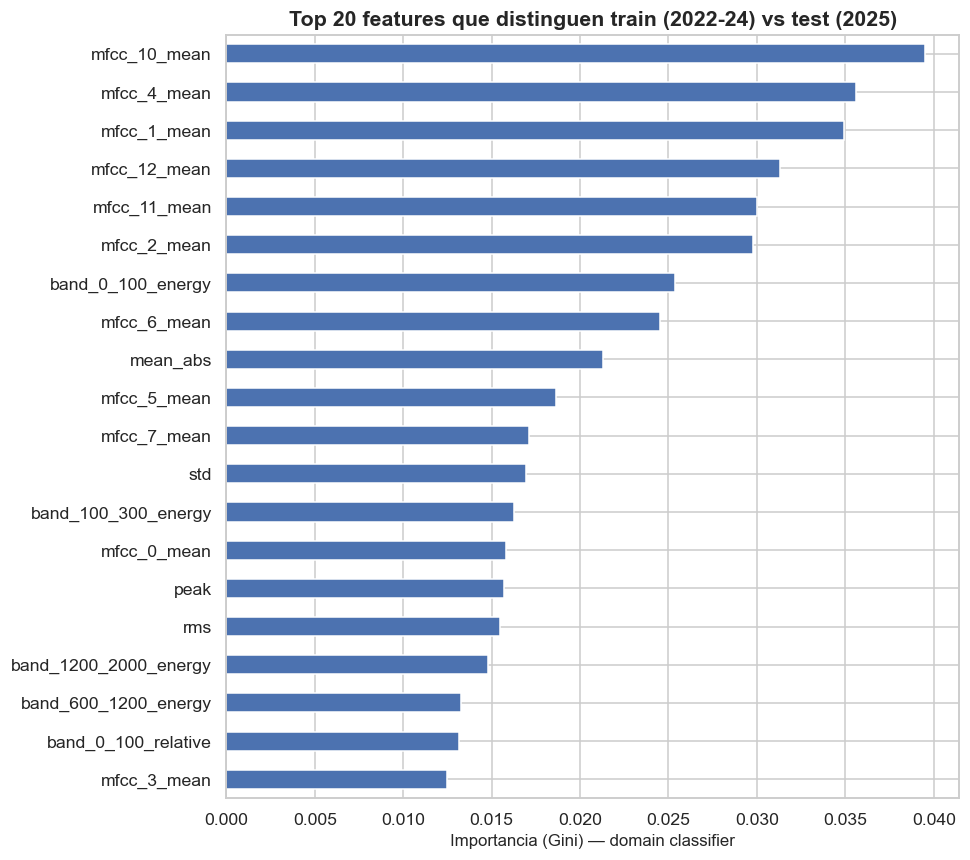

In [66]:
domain_clf.fit(X_all, y_domain)
domain_importances = pd.Series(domain_clf.feature_importances_, index=ALL_SEGMENT_FEATURES).sort_values(ascending=False)

plt.figure(figsize=(9, 8))
domain_importances.head(20).sort_values().plot.barh()
plt.title("Top 20 features que distinguen train (2022-24) vs test (2025)")
plt.xlabel("Importancia (Gini) — domain classifier")
plt.tight_layout()
plt.show()

In [67]:
# Comparar contra las features importantes para el problema REAL (Normal vs Anormal)
comparison = pd.DataFrame({
    "domain_importance": domain_importances,
    "class_importance": importances,  # del clasificador Normal vs Anormal de la etapa 1
}).fillna(0)

comparison["domain_to_class_ratio"] = comparison["domain_importance"] / (comparison["class_importance"] + 1e-6)
print("Features mas 'contaminadas' por dominio (altas en domain, bajas en class):")
display(comparison.sort_values("domain_to_class_ratio", ascending=False).head(15))

Features mas 'contaminadas' por dominio (altas en domain, bajas en class):


,domain_importance,class_importance,domain_to_class_ratio
mfcc_10_mean,0.039479,0.005284,7.469958
mfcc_1_mean,0.034939,0.005891,5.930372
mfcc_12_mean,0.031279,0.005333,5.864128
mfcc_11_mean,0.030013,0.005751,5.218200
mfcc_4_mean,0.035585,0.007159,4.970056
mfcc_6_mean,0.024499,0.005178,4.730870
mfcc_7_mean,0.017103,0.005288,3.233445
band_0_100_energy,0.025373,0.008044,3.153736
band_0_100_relative,0.013175,0.006082,2.166022
mfcc_5_mean,0.018632,0.009504,1.960152


In [68]:
def normalize_per_recording(df, features):
    """Z-score de cada feature usando media/std de la propia grabacion (stem).
    Remueve diferencias de nivel/ganancia entre equipos, preserva forma relativa
    del sonido dentro de cada grabacion."""
    out = df.copy()
    grouped = df.groupby("stem")[features]
    mean = grouped.transform("mean")
    std = grouped.transform("std").replace(0, 1e-6)
    out[features] = (df[features] - mean) / std
    return out

clf_df_norm = normalize_per_recording(clf_df, ALL_SEGMENT_FEATURES)
X_all_norm = imputer_clf.fit_transform(
    clf_df_norm[ALL_SEGMENT_FEATURES].replace([np.inf, -np.inf], np.nan)
)

# Re-chequear domain shift con features normalizadas
oof_domain_norm = cross_val_predict(
    RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    X_all_norm, y_domain, cv=5, method="predict_proba", n_jobs=-1
)[:, 1]
print("AUC domain classifier (features normalizadas por grabacion):",
      round(roc_auc_score(y_domain, oof_domain_norm), 4))

AUC domain classifier (features normalizadas por grabacion): 0.6196


In [69]:
# Reentrenar Normal vs Anormal con features normalizadas
X_train_norm, X_test_norm = X_all_norm[is_train], X_all_norm[~is_train]

clf_bin_norm = RandomForestClassifier(
    n_estimators=400, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
clf_bin_norm.fit(X_train_norm, y_train_bin)
test_pred_norm = clf_bin_norm.predict(X_test_norm)

print("=== Test con normalizacion por grabacion ===")
print(classification_report(y_test_bin, test_pred_norm, target_names=["Normal", "Anormal"]))
print("F1 macro (test, normalizado):", round(f1_score(y_test_bin, test_pred_norm, average="macro"), 4))

=== Test con normalizacion por grabacion ===
              precision    recall  f1-score   support

      Normal       0.46      0.94      0.62      1839
     Anormal       0.44      0.04      0.08      2100

    accuracy                           0.46      3939
   macro avg       0.45      0.49      0.35      3939
weighted avg       0.45      0.46      0.33      3939

F1 macro (test, normalizado): 0.3477


In [70]:
segments_per_recording = clf_df.groupby("stem").size()
print(segments_per_recording.describe())
print()
print("Grabaciones con 1 solo segmento:", (segments_per_recording == 1).sum(),
      f"({(segments_per_recording == 1).mean():.1%} del total)")

count    6205.000000
mean        3.316358
std         1.871259
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
dtype: float64

Grabaciones con 1 solo segmento: 925 (14.9% del total)


In [71]:
contaminated_features = [
    "mfcc_10_mean", "mfcc_1_mean", "mfcc_12_mean", "mfcc_11_mean",
    "mfcc_4_mean", "mfcc_6_mean", "mfcc_7_mean",
    "band_0_100_energy", "band_0_100_relative",
]

clean_features = [f for f in ALL_SEGMENT_FEATURES if f not in contaminated_features]
X_clean = imputer_clf.fit_transform(clf_df[clean_features].replace([np.inf, -np.inf], np.nan))
X_train_clean, X_test_clean = X_clean[is_train], X_clean[~is_train]

clf_bin_clean = RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
clf_bin_clean.fit(X_train_clean, y_train_bin)
test_pred_clean = clf_bin_clean.predict(X_test_clean)

print(classification_report(y_test_bin, test_pred_clean, target_names=["Normal", "Anormal"]))
print("F1 macro (test, features limpias):", round(f1_score(y_test_bin, test_pred_clean, average="macro"), 4))

              precision    recall  f1-score   support

      Normal       0.49      0.96      0.65      1839
     Anormal       0.80      0.14      0.24      2100

    accuracy                           0.52      3939
   macro avg       0.65      0.55      0.44      3939
weighted avg       0.66      0.52      0.43      3939

F1 macro (test, features limpias): 0.4445
